In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Wczytywanie danych

In [ ]:
def fewStationsInOne(dfs, format='%Y-%m-%d'):
    n = len(dfs)
    for i, df in enumerate(dfs):
         df.columns = ['Data', 'Pomiar']
    t = pd.concat(dfs,axis=0,ignore_index=True) if n > 1 else dfs[0]
    t['Data'] = t['Data'].astype(str).str.strip()
    t['Data'] = pd.to_datetime(t['Data'],format=format, dayfirst=True)

    t = t.sort_values(by=['Data','Pomiar'],ascending=[True,False])#.reset_index(drop=True)
    #t = t.drop_duplicates(subset=['Data'], keep='first').reset_index(drop=True)
    t['Pomiar'] = pd.to_numeric(t['Pomiar'].astype(str).str.strip().str.replace(',', '.'), errors='coerce').round(2)
    t.set_index('Data', inplace=True)
    t = t['Pomiar'].resample('D').mean().to_frame().round(2)
    t = t[t.index.year<2025].copy()

    t.loc[t['Pomiar']<0,'Pomiar'] = np.nan # jesli wartosci sa ujemne, zamienia je na NaN
    t = t.loc[t['Pomiar'].first_valid_index():] # ustawia ze df zaczyna sie od nie-NaN wartosci

    return t

#### Dane dla Oslo

In [ ]:
no_pm = pd.read_csv('dane/NO_PM25.csv', sep=';', skiprows=3, usecols=['Tid','Kirkeveien PM2.5 µg/m³ Day'],parse_dates=['Tid'],dayfirst=True )
no_pm_2 = pd.read_csv('dane/NO_PM25_2.csv', sep=';', skiprows=3, usecols=[0,1,9],parse_dates=['Tid'],dayfirst=True)
no_pm_2['Manglerud PM2.5 µg/m³ Day'] = no_pm_2['Manglerud PM2.5 µg/m³ Day'].fillna(no_pm_2['Vahl skole PM2.5 µg/m³ Day'])
no_pm_2 = no_pm_2.drop('Vahl skole PM2.5 µg/m³ Day', axis=1)
no_pm = fewStationsInOne([no_pm,no_pm_2])

In [ ]:
no_no2 = pd.read_csv('dane/NO_NO2.csv', sep=';', skiprows=3, usecols=['Tid','Kirkeveien NO2 µg/m³ Day'],parse_dates=['Tid'])
no_no2 = fewStationsInOne([no_no2],format='%d.%m.%Y %H:%M')

In [ ]:
no_o3 = pd.read_csv('dane/NO_O3.csv', sep=';', skiprows=3, usecols=['Tid','Grønland O3 µg/m³ Day', 'Sofienbergparken O3 µg/m³ Day'],parse_dates=[0],dayfirst=True)
no_o3.columns = ['Data','Pomiar','Sofienbergparken']
no_o3['Pomiar'] = no_o3['Pomiar'].fillna(no_o3['Sofienbergparken'])
no_o3 = no_o3.drop('Sofienbergparken', axis=1)  # O3 w Norwegii ma dane od 2007, troche dziurawe ale doczepie z innej strony
#no_o3[ no_o3['Pomiar'].isna() ]

In [ ]:
no_o3_2 = pd.read_csv('dane/NO_O3_2016-2018_2.csv', sep=',', usecols=['date','o3'],parse_dates=['date'],na_values=' ',skipinitialspace=True)
no_o3_3 = pd.read_csv('dane/NO_O3_2016-2018_3.csv', sep=',', usecols=['date','o3'],parse_dates=['date'],na_values=' ',skipinitialspace=True)

no_o3 = fewStationsInOne([no_o3,no_o3_2,no_o3_3])
#no_o3[ no_o3['Pomiar'].isna() ]

#### Dane dla Londynu

In [ ]:
uk_pm = pd.read_csv('dane/UK/PM25_2014-2024.csv', sep=',', usecols=['ReadingDateTime','Value'],parse_dates=['ReadingDateTime'],dayfirst=True) # jednostka ug/m3
uk_pm_2 = pd.read_csv('dane/UK/PM25_2004-2013.csv', sep=',', header=None, usecols=[2,3], parse_dates=[0], dayfirst=True)
uk_pm = fewStationsInOne([uk_pm,uk_pm_2])

In [ ]:
uk_o3 = pd.read_csv('dane/UK/O3_2014-2024.csv', sep=',',header=None,usecols=[2,3], parse_dates=[0], dayfirst=True) # jednostka ug/m3
uk_o3_2 = pd.read_csv('dane/UK/O3_2004-2013.csv', sep=',', usecols=[2,3], parse_dates=[0], dayfirst=True)
uk_o3 = fewStationsInOne([uk_o3_2, uk_o3])

In [ ]:
uk_so2 = pd.read_csv('dane/UK/SO2_2014-2024.csv', sep=',',usecols=[2,3], parse_dates=[0], dayfirst=True) # jednostka ug/m3
uk_so2_2 = pd.read_csv('dane/UK/SO2_2004-2013.csv', sep=',', usecols=[2,3], parse_dates=[0], dayfirst=True)
uk_so2 = fewStationsInOne([uk_so2_2, uk_so2]) # nawet są ujemne wartosci, cos z nimi zrobic

In [ ]:
uk_no2 = pd.read_csv('dane/UK/NO2_2014-2024.csv', sep=',',usecols=[2,3], parse_dates=[0], dayfirst=True) # jednostka ug/m3
uk_no2_2 = pd.read_csv('dane/UK/NO2_2004-2013.csv', sep=',', usecols=[2,3], parse_dates=[0], dayfirst=True)
uk_no2 = fewStationsInOne([uk_no2_2, uk_no2])

#### Dane dla Warszawy

In [ ]:
pl_no2 = pd.read_csv('dane/WWA/pl_no2_2004-2013.csv', sep=',',header=None, skiprows=1,usecols=[0,1],parse_dates=[0], dayfirst=True,skipinitialspace=True)
pl_no2_2 = pd.read_csv('dane/WWA/pl_no2_2014-2024.csv', sep=',',header=None, skiprows=1,usecols=[0,1],parse_dates=[0], dayfirst=True,skipinitialspace=True)
pl_no2 = fewStationsInOne([pl_no2, pl_no2_2],format='%Y-%m-%d %H:%M')

In [ ]:
pl_so2 = pd.read_csv('dane/WWA/pl_so2_2004-2015.csv', sep=',',header=None, skiprows=1,usecols=[0,1],parse_dates=[0], dayfirst=True)
pl_so2_2 = pd.read_csv('dane/WWA/pl_so2_2016-2018.csv', sep=',',header=None, skiprows=1,usecols=[0,1],parse_dates=[0], dayfirst=True)
pl_so2_3 = pd.read_csv('dane/WWA/pl_so2_2019-2024.csv', sep=',',header=None, skiprows=1,usecols=[0,1],parse_dates=[0], dayfirst=True)
pl_so2 = fewStationsInOne([pl_so2, pl_so2_2, pl_so2_3],format='%Y-%m-%d %H:%M')

In [ ]:
pl_o3 = pd.read_csv('dane/WWA/pl_o3_2004-2013.csv', sep=',',header=None, skiprows=1,usecols=[0,1],parse_dates=[0],skipinitialspace=True, dayfirst=True)
pl_o3_2 = pd.read_csv('dane/WWA/pl_o3_2014-2024.csv', sep=',',header=None, skiprows=1,usecols=[0,1],parse_dates=[0],skipinitialspace=True, dayfirst=True)
pl_o3 = fewStationsInOne([pl_o3, pl_o3_2],format='%Y-%m-%d %H:%M')

In [ ]:
pl_pm = pd.read_csv('dane/WWA/pl_pm_2009-2015.csv', sep=',',header=None, skiprows=1,usecols=[0,1],parse_dates=[0],skipinitialspace=True, dayfirst=True)
pl_pm_2 = pd.read_csv('dane/WWA/pl_pm_2016-2024.csv', sep=',',header=None, skiprows=1,usecols=[0,1],parse_dates=[0],skipinitialspace=True, dayfirst=True)
pl_pm = fewStationsInOne([pl_pm, pl_pm_2],format='%Y-%m-%d %H:%M')

In [ ]:
all_df = [uk_o3, uk_no2, uk_pm, uk_so2,pl_o3, pl_no2, pl_pm, pl_so2,no_o3, no_no2, no_pm]
names_df = ['Londyn O3', 'Londyn NO2', 'Londyn PM 2.5', 'Londyn SO2','Warszawa O3', 'Warszawa NO2', 'Warszawa PM 2.5', 'Warszawa SO2','Oslo O3', 'Oslo NO2', 'Oslo PM 2.5']

In [ ]:
df_all = uk_o3.copy()
for i,tab in enumerate(all_df):
    tab = tab.copy()
    tab['Miasto'] = 'Londyn' if i < 4 else ('Warszawa' if i < 8 else 'Oslo')
    if i%4 == 0:
        tab['Składnik'] = 'O3'
    elif i%1==0:
        tab['Składnik'] = 'NO2'
    elif i%2==0:
        tab['Składnik'] = 'PM 2.5'
    else:
        tab['Składnik'] = 'SO2'
    df_all = pd.concat([df_all, tab],axis=0)

In [ ]:
df_all.describe()

,Pomiar
count,84917.000000
mean,25.310393
std,21.226896
min,0.000000
25%,7.850000
50%,18.810000
75%,38.900000
max,161.640000


In [ ]:
df_all.dtypes

Pomiar      float64
Miasto       object
Składnik     object
dtype: object

### Struktura danych - ile pustych wierszy, statystyki

In [ ]:
summary = []
names_tab = ['Londyn $O_3$', 'Londyn $NO_2$', 'Londyn $PM_{2.5}$', 'Londyn $SO_2$','Warszawa $O_3$', 'Warszawa $NO_2$', 'Warszawa $PM_{2.5}$', 'Warszawa $SO_2$','Oslo $O_3$', 'Oslo $NO_2$', 'Oslo $PM_{2.5}$']
for i,df in enumerate(all_df):
    pomiarow = df['Pomiar'].notnull().sum() # to sa tylko pomiary nie-Null
    sum_null = df['Pomiar'].isnull().sum()
    starting_point = df.index[0].date()
    procent_null = (df['Pomiar'].isnull().sum()/len(df['Pomiar'])*100).round(1)
    odch = round(df['Pomiar'].std(),2)
    sred = round(df['Pomiar'].mean(),2)
    med = df['Pomiar'].median()
    summary.append({'Ilość pomiarów': pomiarow, 'Data rozpoczęcia pomiarów': starting_point,'Średnia': sred,'Mediana':med,'Odchylenie standardowe': odch,
                    'Procent pustych rekordów': f'{procent_null}%'})


order = {
    'O_3': 0,
    'NO_2': 1,
    'PM_{2.5}': 2,
    'SO_2': 3
}

summary_df = pd.DataFrame(summary,index =names_tab)
summary_df = summary_df.sort_index(
    key=lambda idx: idx.map(
        lambda x: order[[k for k in order if k in x][0]]
    )
)
summary_df

,Ilość pomiarów,Data rozpoczęcia pomiarów,Średnia,Mediana,Odchylenie standardowe,Procent pustych rekordów
Londyn $O_3$,7384,2004-01-01,44.06,45.20,19.38,3.7%
Warszawa $O_3$,7243,2004-01-01,46.29,46.81,21.52,5.6%
Oslo $O_3$,5847,2007-03-08,40.32,38.52,19.15,10.2%
Londyn $NO_2$,7644,2004-01-01,26.00,23.20,14.94,0.3%
Warszawa $NO_2$,7389,2004-01-01,22.28,20.48,10.24,3.7%
Oslo $NO_2$,7227,2004-01-01,31.32,27.42,20.22,5.8%
Londyn $PM_{2.5}$,7027,2004-12-21,13.58,10.10,10.18,3.9%
Warszawa $PM_{2.5}$,5259,2009-06-03,19.47,15.37,14.31,7.6%
Oslo $PM_{2.5}$,7644,2004-01-01,9.21,7.91,5.23,0.4%
Londyn $SO_2$,7342,2004-01-01,3.60,2.80,3.02,4.3%


In [ ]:
for i, tab in enumerate([no_o3]):
    tab = tab.copy()
    tab['Rok'] = tab.index.year
    print(tab[tab['Pomiar'].isna()].groupby('Rok').size())

Rok
2007     20
2009      9
2010     96
2011    262
2012     62
2013      3
2014     12
2017      7
2018     33
2019      7
2020      9
2021     20
2022     62
2023     20
2024     40
dtype: int64


### Uzupełnianie missing values na podstawie danych historycznych (STL decomposition for time series)

In [ ]:
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL

In [ ]:
def devideDate(df):
    #df = df.copy()
    df.loc[:, 'Rok'] = df.index.year
    df.loc[:, 'Miesiac'] = df.index.month
    df.loc[:, 'Dzien'] = df.index.day
    df.loc[:, 'Dzien_tygodnia'] = df.index.dayofweek
    #df.loc[:, 'Nazwa_dnia'] = df.index.day_name()
    df.loc[:, 'Dzien_roku'] = df.index.dayofyear
    #if any(df.index.hour) == True:
     #   df.loc[:, 'Godzina'] = df.index.time # wwa ma czas
    return df

In [ ]:
for tab in [no_o3,no_pm,no_no2, uk_o3, uk_pm, uk_no2, uk_so2, pl_o3, pl_pm, pl_no2, pl_so2]:
    devideDate(tab)

In [ ]:
# STL decom
all_missing = []
for i,tab in enumerate(all_df):
    df = tab.copy()
    missing_id = tab[tab['Pomiar'].isnull()].index
    stl = STL(df['Pomiar'].interpolate(),period=365)
    result = stl.fit()
    sez = result.seasonal
    desezoned = df['Pomiar'] - sez
    interpolated = desezoned.interpolate(method='linear') + sez
    all_df[i].loc[missing_id,'Pomiar'] = interpolated[missing_id]
    all_df[i].loc[all_df[i]['Pomiar']<0, 'Pomiar'] = 0 # jesli obliczy wartosc ujemna, to wstawia 0
    all_missing.append(missing_id)

uk_o3, uk_no2, uk_pm, uk_so2,pl_o3, pl_no2, pl_pm, pl_so2,no_o3, no_no2, no_pm = all_df

In [ ]:
# sprawdzenie
summary_test = []
names_tab = ['Londyn $O_3$', 'Londyn $NO_2$', 'Londyn $PM_{2.5}$', 'Londyn $SO_2$','Warszawa $O_3$', 'Warszawa $NO_2$', 'Warszawa $PM_{2.5}$', 'Warszawa $SO_2$','Oslo $O_3$', 'Oslo $NO_2$', 'Oslo $PM_{2.5}$']
for i,df in enumerate(all_df):
    pomiarow = df['Pomiar'].notnull().sum() # to sa tylko pomiary nie-Null
    sum_null = df['Pomiar'].isnull().sum()
    starting_point = df.index[0].date()
    procent_null = (df['Pomiar'].isnull().sum()/len(df['Pomiar'])*100).round(1)
    odch = round(df['Pomiar'].std(),2)
    sred = round(df['Pomiar'].mean(),2)
    med = df['Pomiar'].median()
    summary_test.append({'Ilość pomiarów': pomiarow, 'Data rozpoczęcia pomiarów': starting_point,'Średnia': sred,'Mediana':med,'Odchylenie standardowe': odch,
                    'Procent pustych rekordów': f'{procent_null}%'})


order = {
    'O_3': 0,
    'NO_2': 1,
    'PM_{2.5}': 2,
    'SO_2': 3
}

summary_t = pd.DataFrame(summary_test,index =names_tab)
summary_t = summary_t.sort_index(
    key=lambda idx: idx.map(
        lambda x: order[[k for k in order if k in x][0]]
    )
)
summary_t

,Ilość pomiarów,Data rozpoczęcia pomiarów,Średnia,Mediana,Odchylenie standardowe,Procent pustych rekordów
Londyn $O_3$,7670,2004-01-01,43.69,44.90,19.55,0.0%
Warszawa $O_3$,7671,2004-01-01,46.04,46.49,21.32,0.0%
Oslo $O_3$,6509,2007-03-08,41.23,40.50,18.97,0.0%
Londyn $NO_2$,7670,2004-01-01,25.98,23.15,14.93,0.0%
Warszawa $NO_2$,7671,2004-01-01,22.22,20.43,10.11,0.0%
Oslo $NO_2$,7671,2004-01-01,31.22,27.46,20.00,0.0%
Londyn $PM_{2.5}$,7315,2004-12-21,13.52,10.10,10.11,0.0%
Warszawa $PM_{2.5}$,5691,2009-06-03,19.38,15.48,14.00,0.0%
Oslo $PM_{2.5}$,7671,2004-01-01,9.22,7.92,5.24,0.0%
Londyn $SO_2$,7670,2004-01-01,3.56,2.80,3.01,0.0%


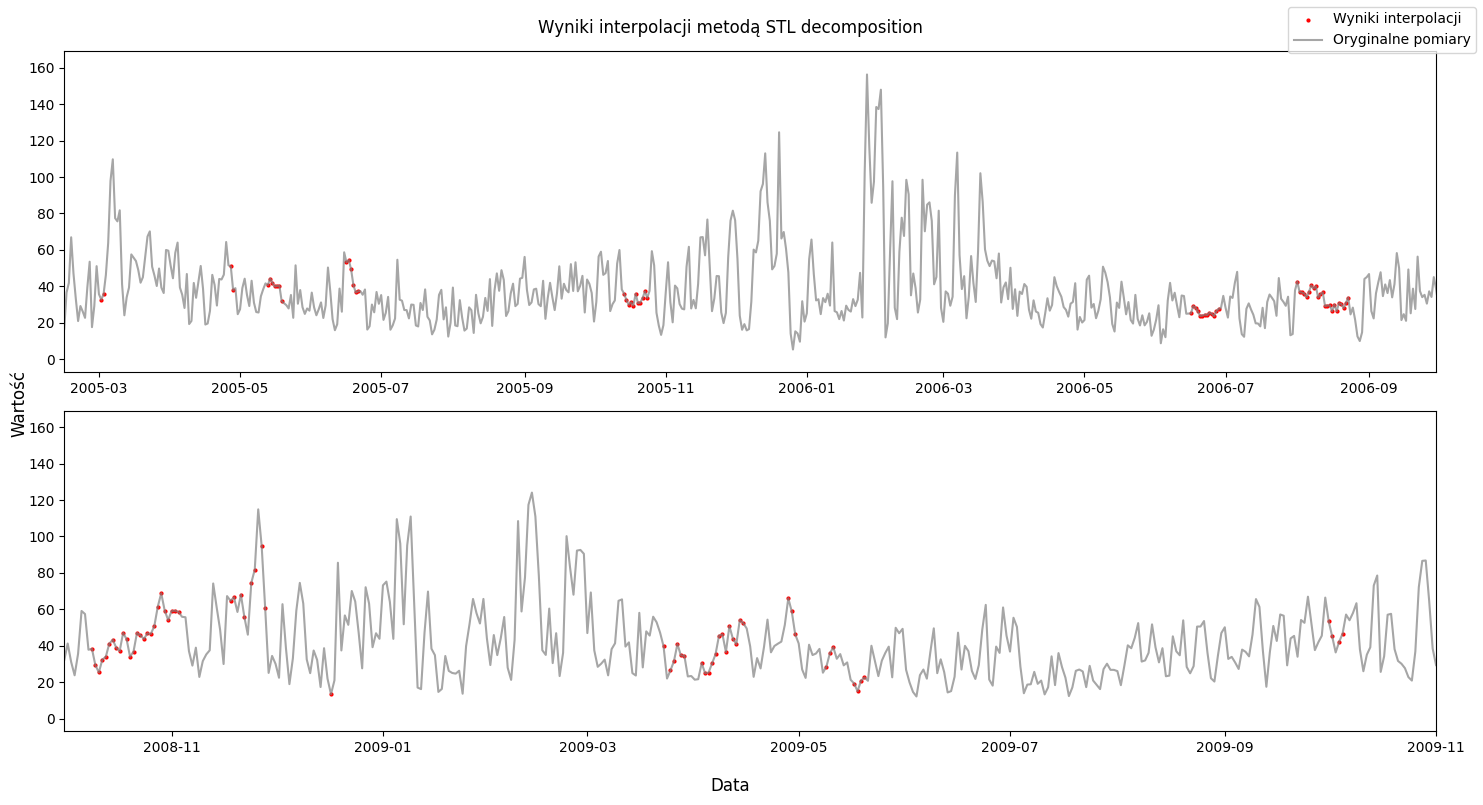

In [ ]:
data = ['2005-02-14','2006-09-30','2008-10-01','2009-11-01'] # moze wystarczy jeden wykres

fig,ax = plt.subplots(2,1,figsize=(15,8))
plt.suptitle('Wyniki interpolacji metodą STL decomposition')
fig.supxlabel('Data')
fig.supylabel('Wartość')

ax[0].scatter(no_no2.loc[all_missing[9]].index, no_no2.loc[all_missing[9], 'Pomiar'], color='red',s=4,label='Wyniki interpolacji')
ax[0].plot(no_no2.index, no_no2['Pomiar'],color='grey',alpha=0.7,label='Oryginalne pomiary')
ax[0].set_xlim(pd.to_datetime(data[0]), pd.to_datetime(data[1]))
ax[1].scatter(no_no2.loc[all_missing[9]].index, no_no2.loc[all_missing[9], 'Pomiar'], color='red',s=4)
ax[1].plot(no_no2.index, no_no2['Pomiar'],color='grey',alpha=0.7)
ax[1].set_xlim(pd.to_datetime(data[2]), pd.to_datetime(data[3]))
fig.legend()
plt.tight_layout()
plt.show()

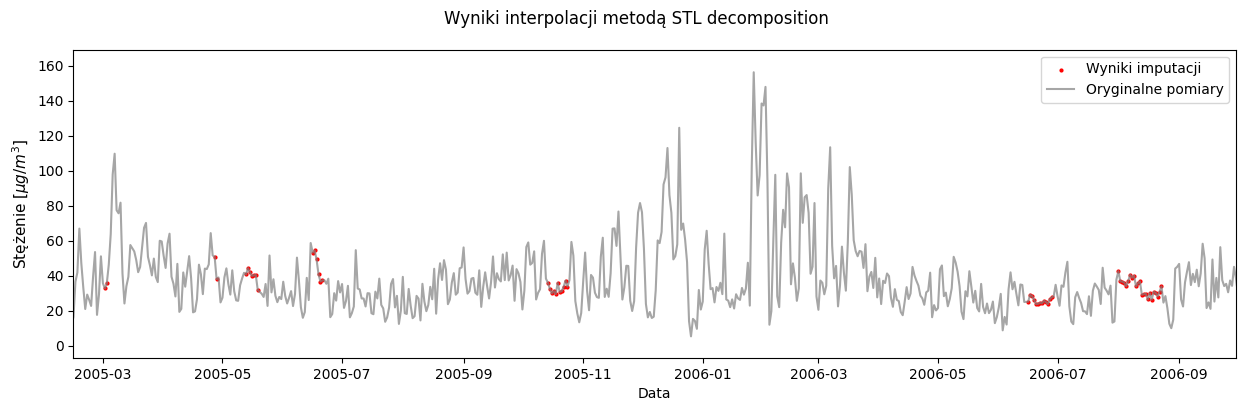

In [ ]:
data = ['2005-02-14','2006-09-30','2008-10-01','2009-11-01']

fig,ax = plt.subplots(figsize=(15,4))
plt.suptitle('Wyniki interpolacji metodą STL decomposition')

ax.scatter(no_no2.loc[all_missing[9]].index, no_no2.loc[all_missing[9], 'Pomiar'], color='red',s=4,label='Wyniki imputacji')
ax.plot(no_no2.index, no_no2['Pomiar'],color='grey',alpha=0.7,label='Oryginalne pomiary')
ax.set_xlim(pd.to_datetime(data[0]), pd.to_datetime(data[1]))
ax.set_xlabel('Data')
ax.set_ylabel(r'Stężenie $[µg/m^3]$',fontsize=11)
ax.legend()
plt.show()

In [ ]:
kolory = ['#78C841','#F75270', '#3396D3','#FF9B2F']

### Pomiary (wyświetlenie danych)

In [ ]:
markers= ['o']

def wieloletnie(df, components, title):
    n = len(components)
    fig, ax = plt.subplots(n,1,figsize=(15,3.5*n))
    fig.supxlabel('Data',fontsize=13)
    fig.supylabel('Wartość [ug/m3]',fontsize=13)
    plt.suptitle(f'Wartości wieloletnie w {title}',fontsize=16)
    for i,tab in enumerate(df):
        ax[i].plot(tab.index, tab['Pomiar'], label=f'{components[i]}',color=kolory[i],alpha=0.7)
        #ax[i].set_title(f'Wartości {components[i]}')
        ax[i].grid(True)
        ax[i].legend(loc='upper right')
    plt.tight_layout()

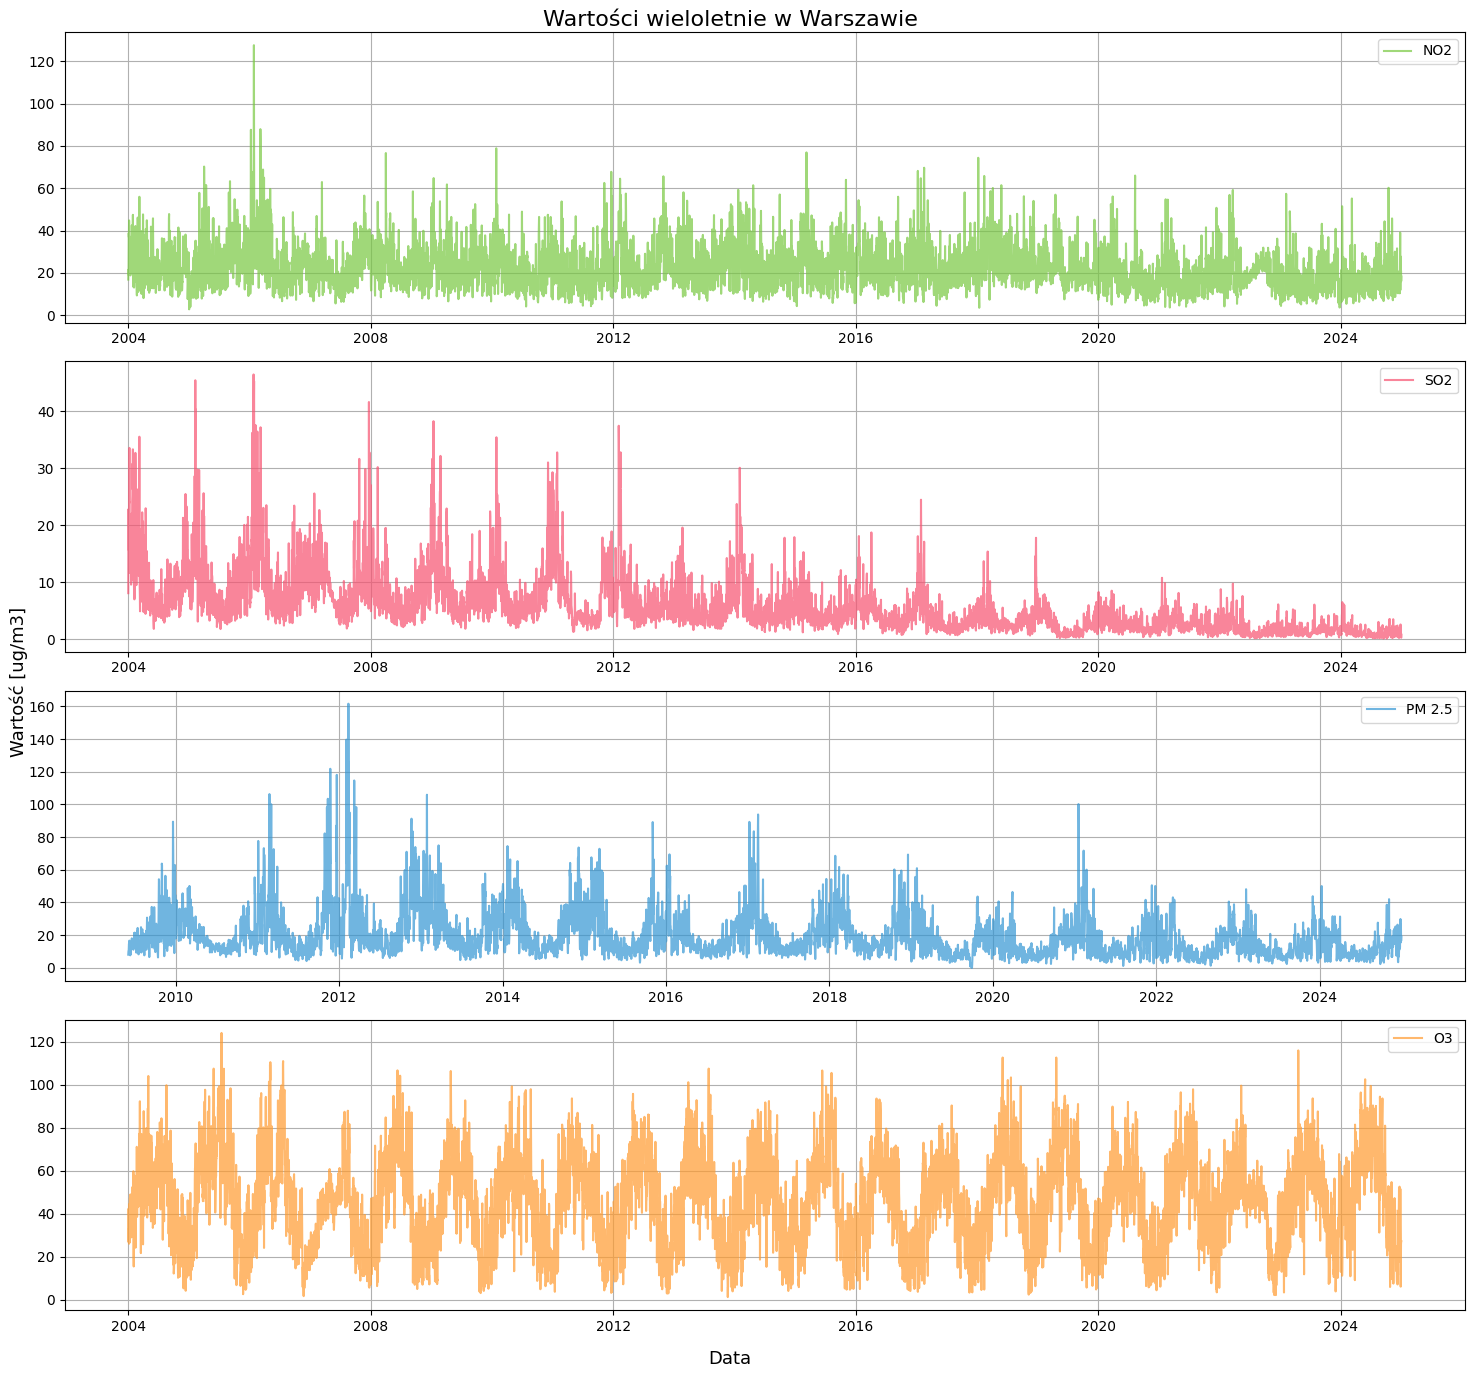

In [ ]:
wieloletnie([pl_no2, pl_so2,pl_pm,pl_o3],components=['NO2', 'SO2','PM 2.5','O3'],title='Warszawie')

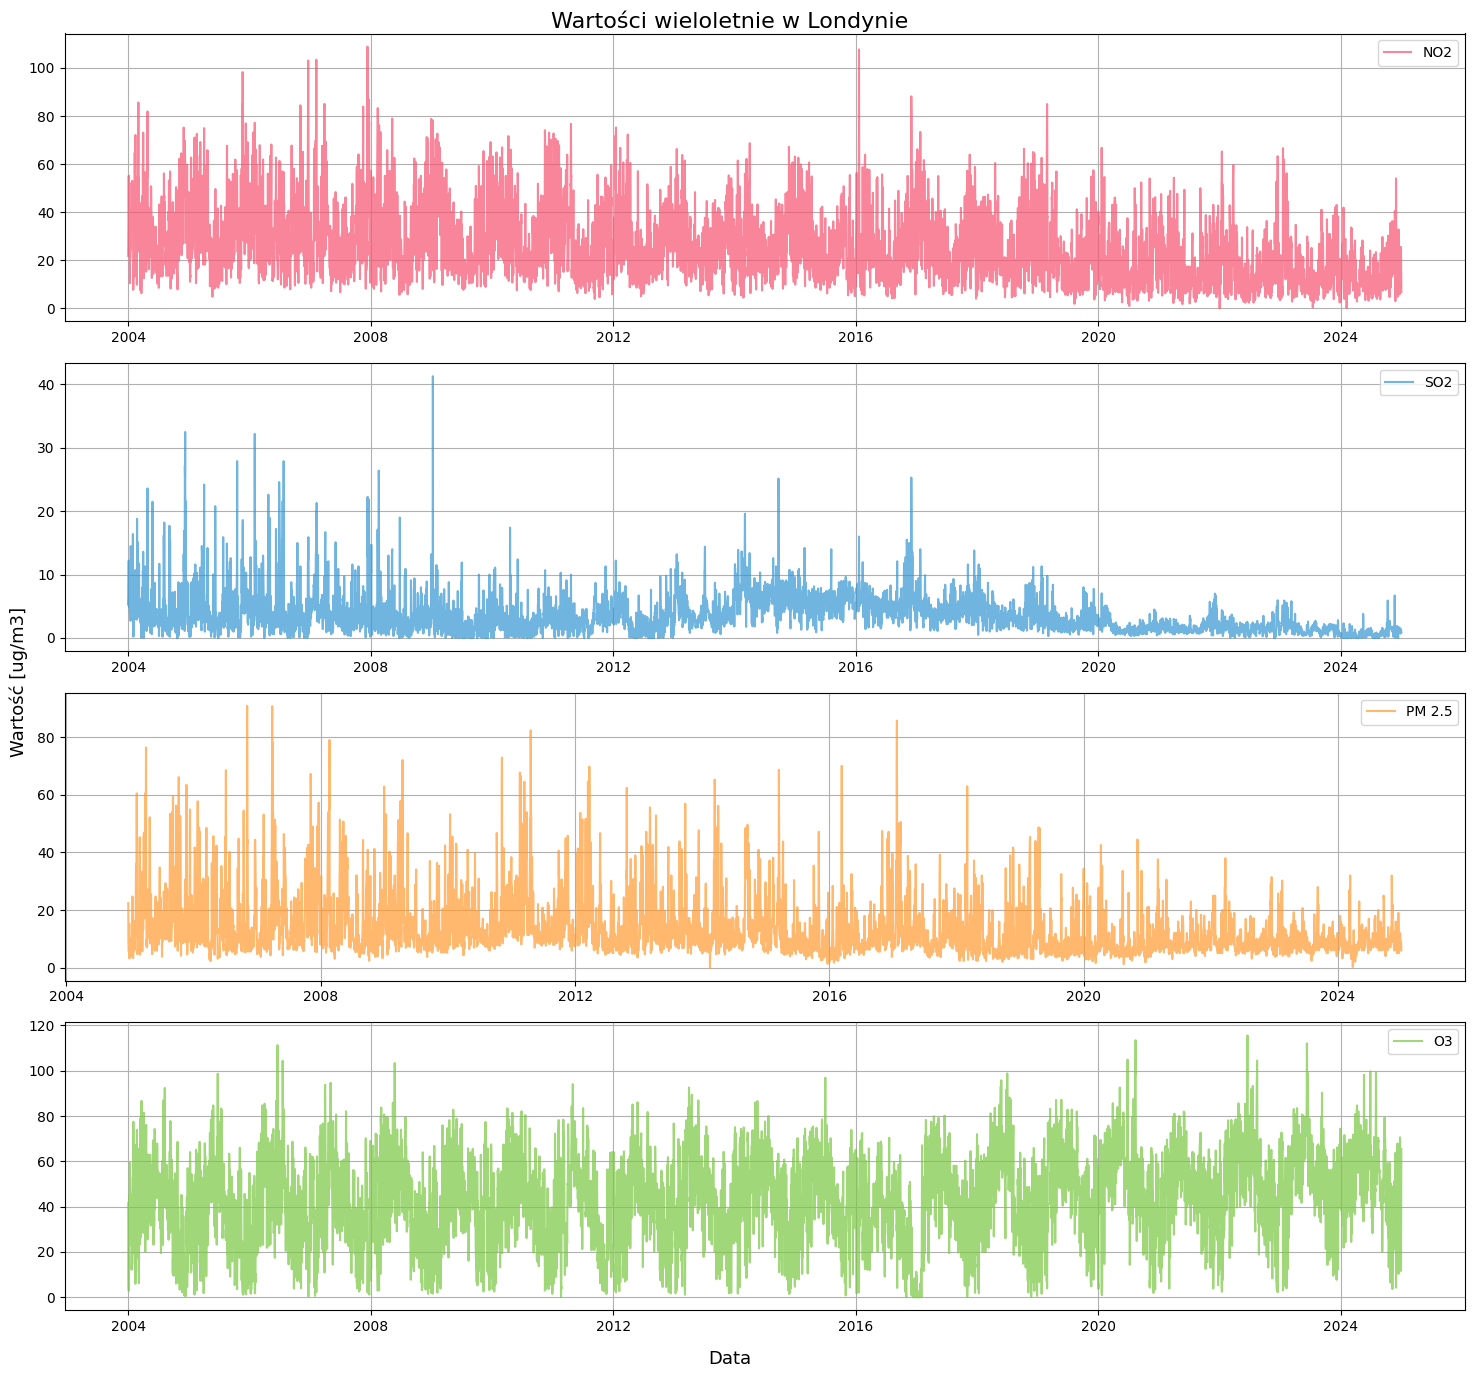

In [ ]:
wieloletnie([uk_no2, uk_so2,uk_pm,uk_o3],components=['NO2', 'SO2','PM 2.5','O3'],title='Londynie')

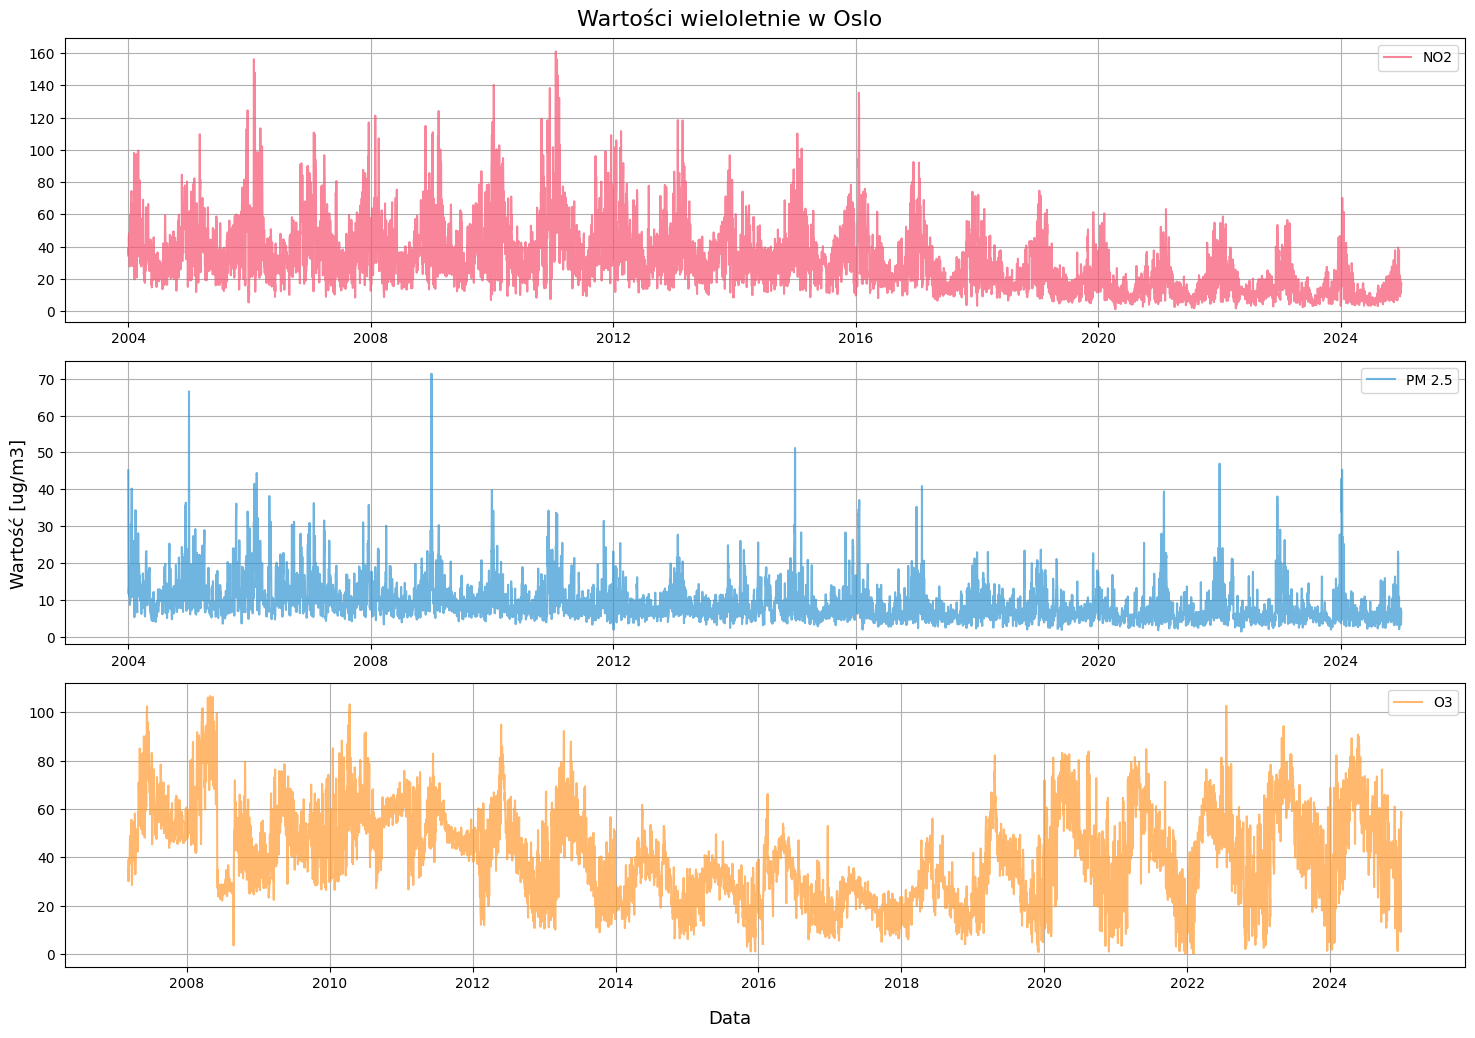

In [ ]:
wieloletnie([no_no2,no_pm,no_o3],components=['NO2','PM 2.5','O3'],title='Oslo')

## Analizy

### 1. Analiza PCA

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

In [ ]:
pl_o3_d = pl_o3[['Pomiar']].resample('D').mean().round(2).copy() # df godzinne -> dobowe dla polski
pl_no2_d = pl_no2[['Pomiar']].resample('D').mean().round(2).copy()
pl_pm_d = pl_pm[['Pomiar']].resample('D').mean().round(2).copy()

In [ ]:
temp = [uk_o3, uk_no2, uk_pm,pl_o3_d, pl_no2_d, pl_pm_d,no_o3, no_no2, no_pm]
temp_names = ['Londyn O3', 'Londyn NO2', 'Londyn PM 2.5','Warszawa O3', 'Warszawa NO2', 'Warszawa PM 2.5','Oslo O3', 'Oslo NO2', 'Oslo PM 2.5']
df_combined= pd.concat(temp, axis=1)
df_combined = df_combined[df_combined.index.year> 2009].copy() # mozna zamienic ze od pierwszego indexu ktory nie jest pusty
df_combined = df_combined['Pomiar']
df_combined.columns = temp_names
df_combined = df_combined.dropna(axis=0)
df_combined.head()

,Londyn O3,Londyn NO2,Londyn PM 2.5,Warszawa O3,Warszawa NO2,Warszawa PM 2.5,Oslo O3,Oslo NO2,Oslo PM 2.5
Data,,,,,,,,,
2010-01-01,41.1,32.75,11.33,52.34,15.08,20.40,55.60,10.37,8.13
2010-01-02,22.0,41.40,13.70,35.79,20.04,18.06,49.23,28.10,16.62
2010-01-03,21.4,29.50,13.57,34.01,17.15,20.08,33.57,59.47,27.04
2010-01-04,3.5,63.20,32.40,27.80,34.60,21.48,30.06,117.40,31.44
2010-01-05,8.3,58.25,22.60,30.50,38.70,41.41,38.78,63.53,19.41


In [ ]:
scaler = StandardScaler() # standaryzja
df_scaled = scaler.fit_transform(df_combined)

df_scaled = pd.DataFrame(df_scaled, columns=df_combined.columns, index=df_combined.index)

In [ ]:
df_scaled.head()

,Londyn O3,Londyn NO2,Londyn PM 2.5,Warszawa O3,Warszawa NO2,Warszawa PM 2.5,Oslo O3,Oslo NO2,Oslo PM 2.5
Data,,,,,,,,,
2010-01-01,-0.208088,0.696285,-0.113034,0.296332,-0.656842,0.079824,0.895167,-0.901857,0.009647
2010-01-02,-1.197583,1.333450,0.148905,-0.488339,-0.150465,-0.086965,0.549709,0.023613,1.902293
2010-01-03,-1.228667,0.456888,0.134537,-0.572733,-0.445512,0.057015,-0.299565,1.661065,4.225187
2010-01-04,-2.155995,2.939253,2.215681,-0.867162,1.335997,0.156804,-0.489920,4.684894,5.206064
2010-01-05,-1.907326,2.574633,1.132558,-0.739149,1.754575,1.577363,-0.017016,1.872988,2.524258


##### Jaką liczbę komponentów podać do PCA

In [ ]:
from sklearn.decomposition import PCA
pca = PCA().fit(df_scaled)
wyjasniona_wariancja = pca.explained_variance_ratio_ # zwraca wektor wyjasnionej wariancji przez kazdy wymiar osobno
wyjasniona_wariancja

array([0.39891223, 0.15091632, 0.11596068, 0.1077744 , 0.06111339,
       0.04921281, 0.04436067, 0.04354946, 0.02820004])

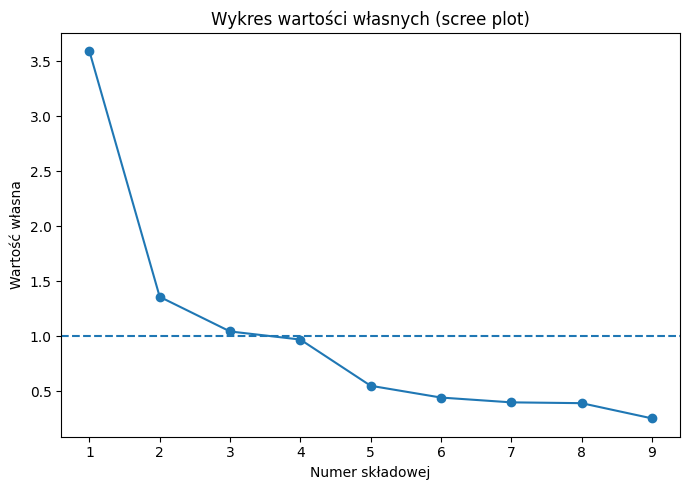

In [ ]:
eigenvalues = pca.explained_variance_

plt.figure(figsize=(7,5))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o')
plt.axhline(y=1, linestyle='--')
plt.xlabel('Numer składowej')
plt.ylabel('Wartość własna')
plt.title('Wykres wartości własnych (scree plot)')
plt.tight_layout()
plt.show()




In [ ]:
pca.explained_variance_

array([3.59086562, 1.35849487, 1.04383668, 0.97014669, 0.55012089,
       0.44299613, 0.39931895, 0.39201666, 0.25384674])

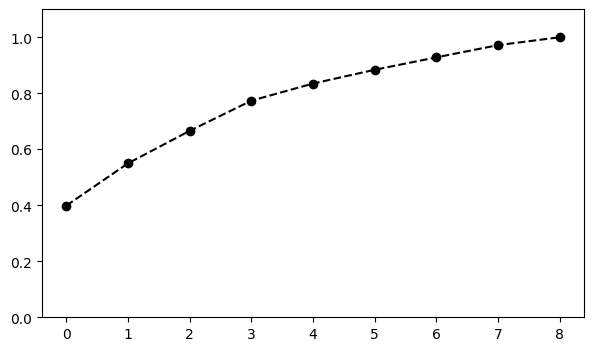

In [ ]:
#plt.plot(explained_variance_ratio.cumsum()) 67-55
fig, ax = plt.subplots(figsize=(7,4))
plt.ylim(0.0,1.1)
plt.plot(np.arange(0, 9, step=1), wyjasniona_wariancja.cumsum(), marker='o',linestyle='--', color='black')
plt.show()

In [ ]:
N = 3 # ile komponentow. 3 wyjasnia 71%, 4 - 80%

pca = PCA(n_components = N)
res = pca.fit_transform(df_scaled)
res_df = pd.DataFrame(res, index=df_combined.index, columns=['PC1','PC2','PC3'])
res_df.head()

,PC1,PC2,PC3
Data,,,
2010-01-01,-0.502117,0.729870,-0.334685
2010-01-02,1.548345,1.027027,-0.249266
2010-01-03,2.724374,1.056019,0.716284
2010-01-04,6.819351,2.948129,1.443546
2010-01-05,4.861105,1.060545,0.912905


In [ ]:
df_pcs = pd.DataFrame(res_df, columns=['PC1','PC2','PC3'], index=df_scaled.index)
pca_comp_cities = pd.DataFrame(pca.components_.T, index=df_scaled.columns,columns=['PC1','PC2','PC3'])

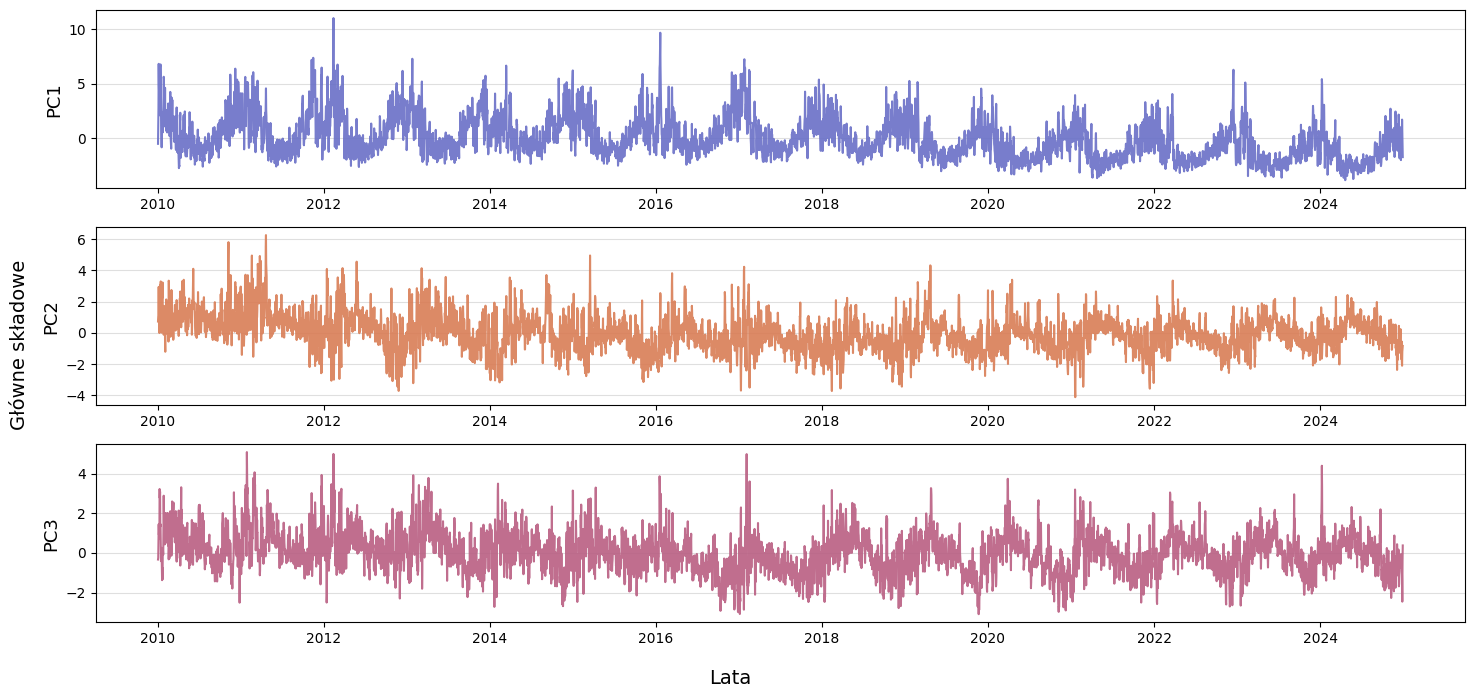

In [ ]:
pc_kolory = ['#696FC7','#D97D55','#B95E82','#3CB371']

fig, ax = plt.subplots(N,1,figsize=(15,7))
fig.supxlabel('Lata',fontsize=14)
fig.supylabel('Główne składowe',fontsize=14)
for i,col in enumerate(res_df.columns):
    ax[i].plot(res_df.index, res_df[col], color=pc_kolory[i],alpha=0.9, label=col)
    #ax[i].legend(loc='upper right')
    ax[i].set_ylabel(col,fontsize=13)
    ax[i].grid(True,axis='y',alpha=0.4)
plt.tight_layout()
plt.show()

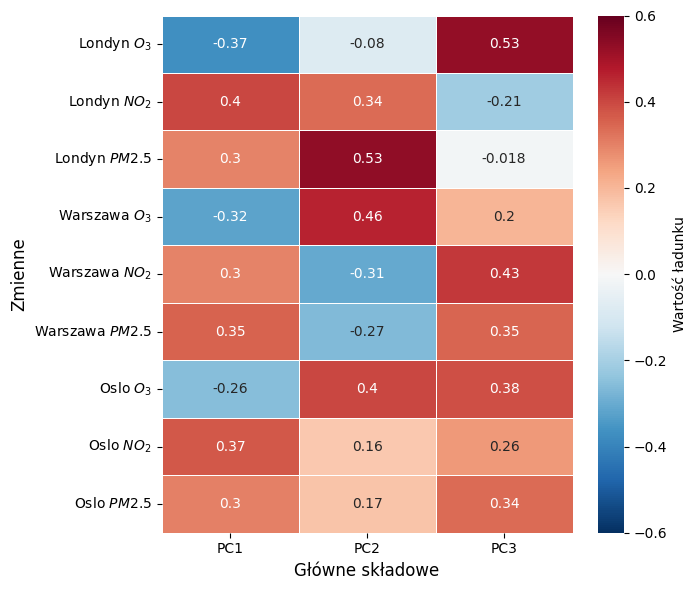

In [ ]:
plt.figure(figsize=(7,6))
new_names = [r'Londyn $O_3$', r'Londyn $NO_2$', r'Londyn $PM_{2.5}$',r'Warszawa $O_3$', r'Warszawa $NO_2$', r'Warszawa $PM_{2.5}$',
             r'Oslo $O_3$', r'Oslo $NO_2$', r'Oslo $PM_{2.5}$']
ax = sns.heatmap(pca_comp_cities, annot=True, cmap='RdBu_r',linewidth=0.5,vmin=-0.6,vmax=0.6)
ax.figure.axes[-1].set_ylabel('Wartość ładunku', size=10)
plt.yticks(np.arange(len(new_names)) + 0.5, new_names)
plt.xlabel('Główne składowe',fontsize=12)
plt.ylabel('Zmienne',fontsize=12)
plt.tight_layout()
plt.show()

# pca_comp_cities # df zamiast heatmapy

### 2. Analiza trendów długookresowych

In [ ]:
def roczne(df, components, title):
    fig, ax = plt.subplots(figsize=(15,5))
    ax.set_xlabel('Rok',fontsize=11)
    ax.set_ylabel(r'Stężenie $[µg/m^3]$',fontsize=11)   #r'Oslo $O_3$'
    ax.set_xticks(range(2004,2025))
    ax.set_title(f'Średnie roczne wartości w {title}',fontsize=14)
    for i,tab in enumerate(df):
        mask = (tab.index.month==1) & (tab.index.day==1)
        start = tab.index[mask][0]
        tab = tab.loc[start:]
        grouped = tab.groupby('Rok')['Pomiar'].mean().reset_index()
        ax.scatter(grouped['Rok'], grouped['Pomiar'],color=kolory[i], label=f'{components[i]}')
        ax.plot(grouped['Rok'], grouped['Pomiar'],color=kolory[i],linestyle='--')
        ax.grid(True)
    #ax.legend(loc="upper right")
    fig.legend(loc='center left',
    bbox_to_anchor=(0.9, 0.5))

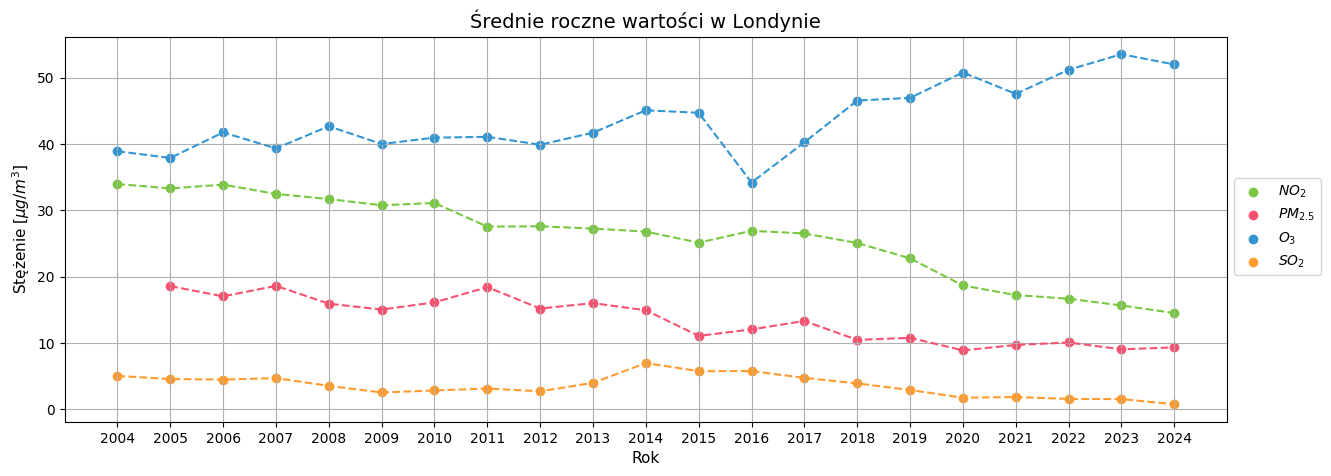

In [ ]:
rok = roczne([uk_no2,uk_pm,uk_o3,uk_so2],components=[r'$NO_2$',r'$PM_{2.5}$',r'$O_3$', r'$SO_2$'],title='Londynie')

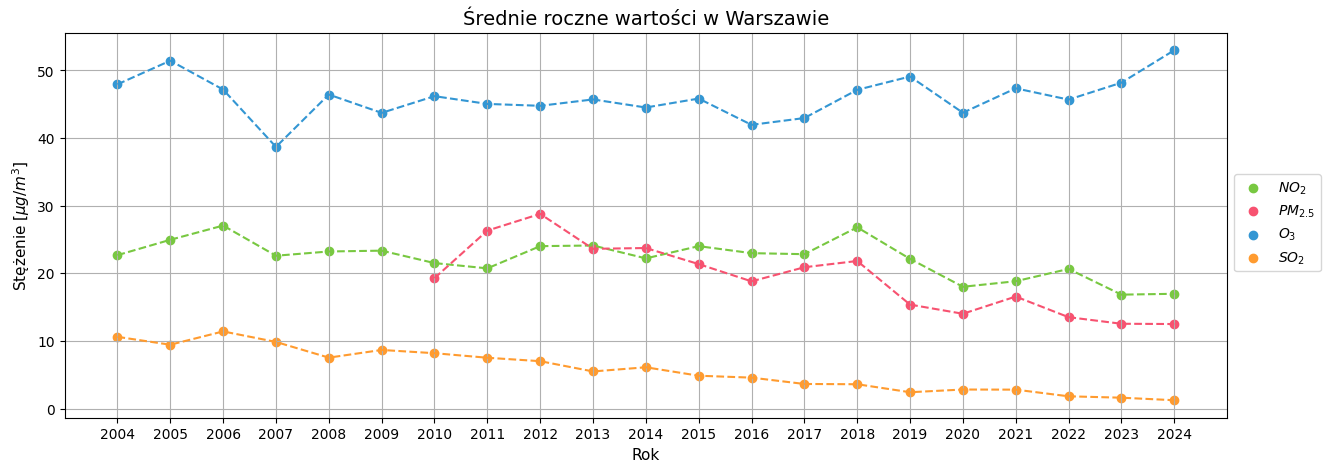

In [ ]:
roczne([pl_no2,pl_pm,pl_o3, pl_so2],components=[r'$NO_2$',r'$PM_{2.5}$',r'$O_3$', r'$SO_2$'],title='Warszawie')

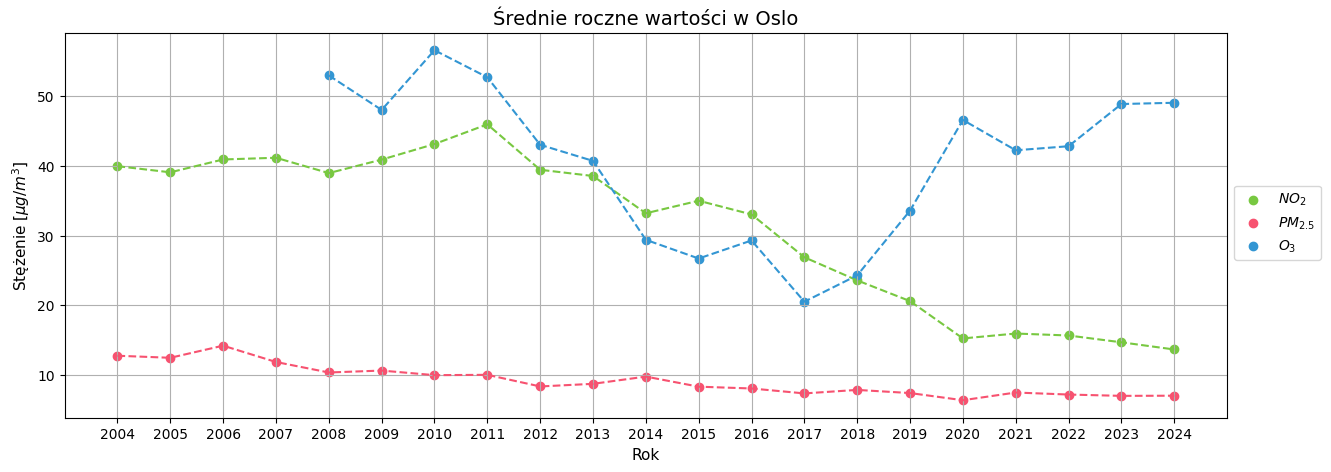

In [ ]:
roczne([no_no2,no_pm,no_o3],components=[r'$NO_2$',r'$PM_{2.5}$',r'$O_3$'],title='Oslo')

### 3. Analiza sezonowości

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
sez_uk_pm = seasonal_decompose(uk_pm['Pomiar'], model='additive',period=365)
sez_uk_o3 = seasonal_decompose(uk_o3['Pomiar'], model='additive',period=365)
sez_uk_no2 = seasonal_decompose(uk_no2['Pomiar'], model='additive',period=365)
sez_uk_so2 = seasonal_decompose(uk_so2['Pomiar'], model='additive',period=365)

sez_pl_pm = seasonal_decompose(pl_pm['Pomiar'], model='additive',period=365)
sez_pl_o3 = seasonal_decompose(pl_o3['Pomiar'], model='additive',period=365)
sez_pl_no2 = seasonal_decompose(pl_no2['Pomiar'], model='additive',period=365)
sez_pl_so2 = seasonal_decompose(pl_so2['Pomiar'], model='additive',period=365)

sez_no_pm = seasonal_decompose(no_pm['Pomiar'], model='additive',period=365)
sez_no_o3 = seasonal_decompose(no_o3['Pomiar'], model='additive',period=365)
sez_no_no2 = seasonal_decompose(no_no2['Pomiar'], model='additive',period=365)

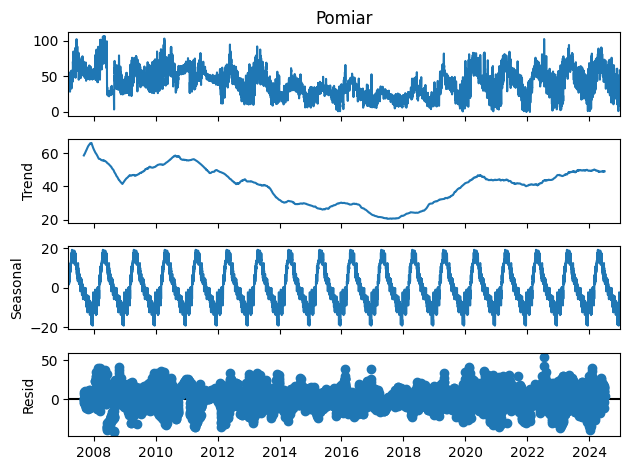

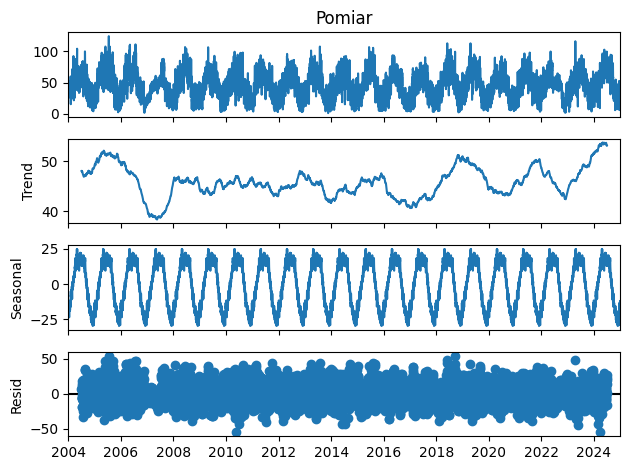

In [ ]:
sez_no_o3.plot()
plt.show()

sez_pl_o3.plot()
plt.show()

#### ACF (sezonowość według miasta)

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf, month_plot

In [ ]:
def acf_funkcja(df, components, city, lag_num=365):
    n = len(df)
    fig, ax = plt.subplots(n,1,figsize=(13,3.5*n))
    #plt.suptitle(f'ACF w {city}',fontsize=18)
   # fig.supxlabel('Lag',fontsize=15)
    #fig.supylabel('ACF',fontsize=15)
    for i in range(n):
        plot_acf(df[i], lags=lag_num,ax=ax[i])
        ax[i].axvline(x=7,color='red',ymin=0.5,ymax=1,linestyle='--',label='Opóźnienie po 7 dniach')
        ax[i].set_title(f'{components[i]}',fontsize=10)
        ax[i].set_xlabel('Opóźnienie [dni]',fontsize=13)
        ax[i].set_ylabel('ACF',fontsize=13)
        ax[i].grid(True)
        ax[i].legend(fontsize=11)
    plt.tight_layout()
    plt.show()

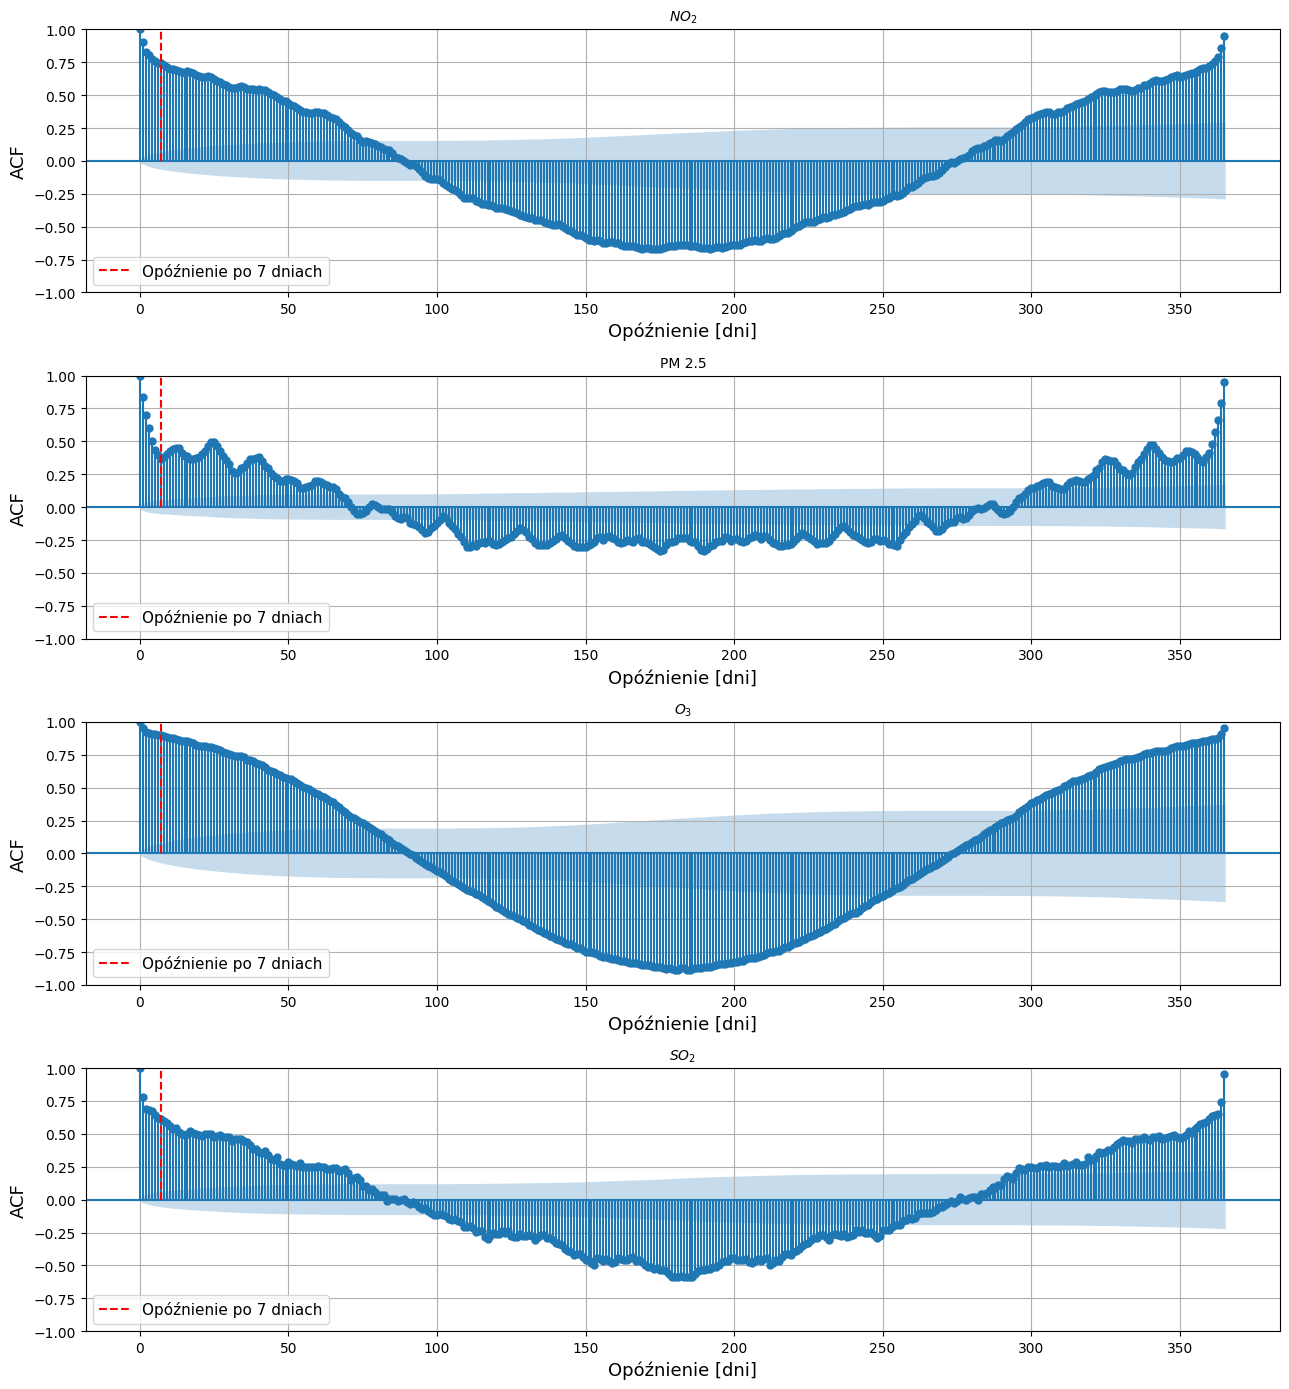

In [ ]:
acf_funkcja([sez_uk_no2.seasonal,sez_uk_pm.seasonal, sez_uk_o3.seasonal,sez_uk_so2.seasonal],[r'$NO_2$',r'$PM_{2.5}$',r'$O_3$', r'$SO_2$'],'Londynie')

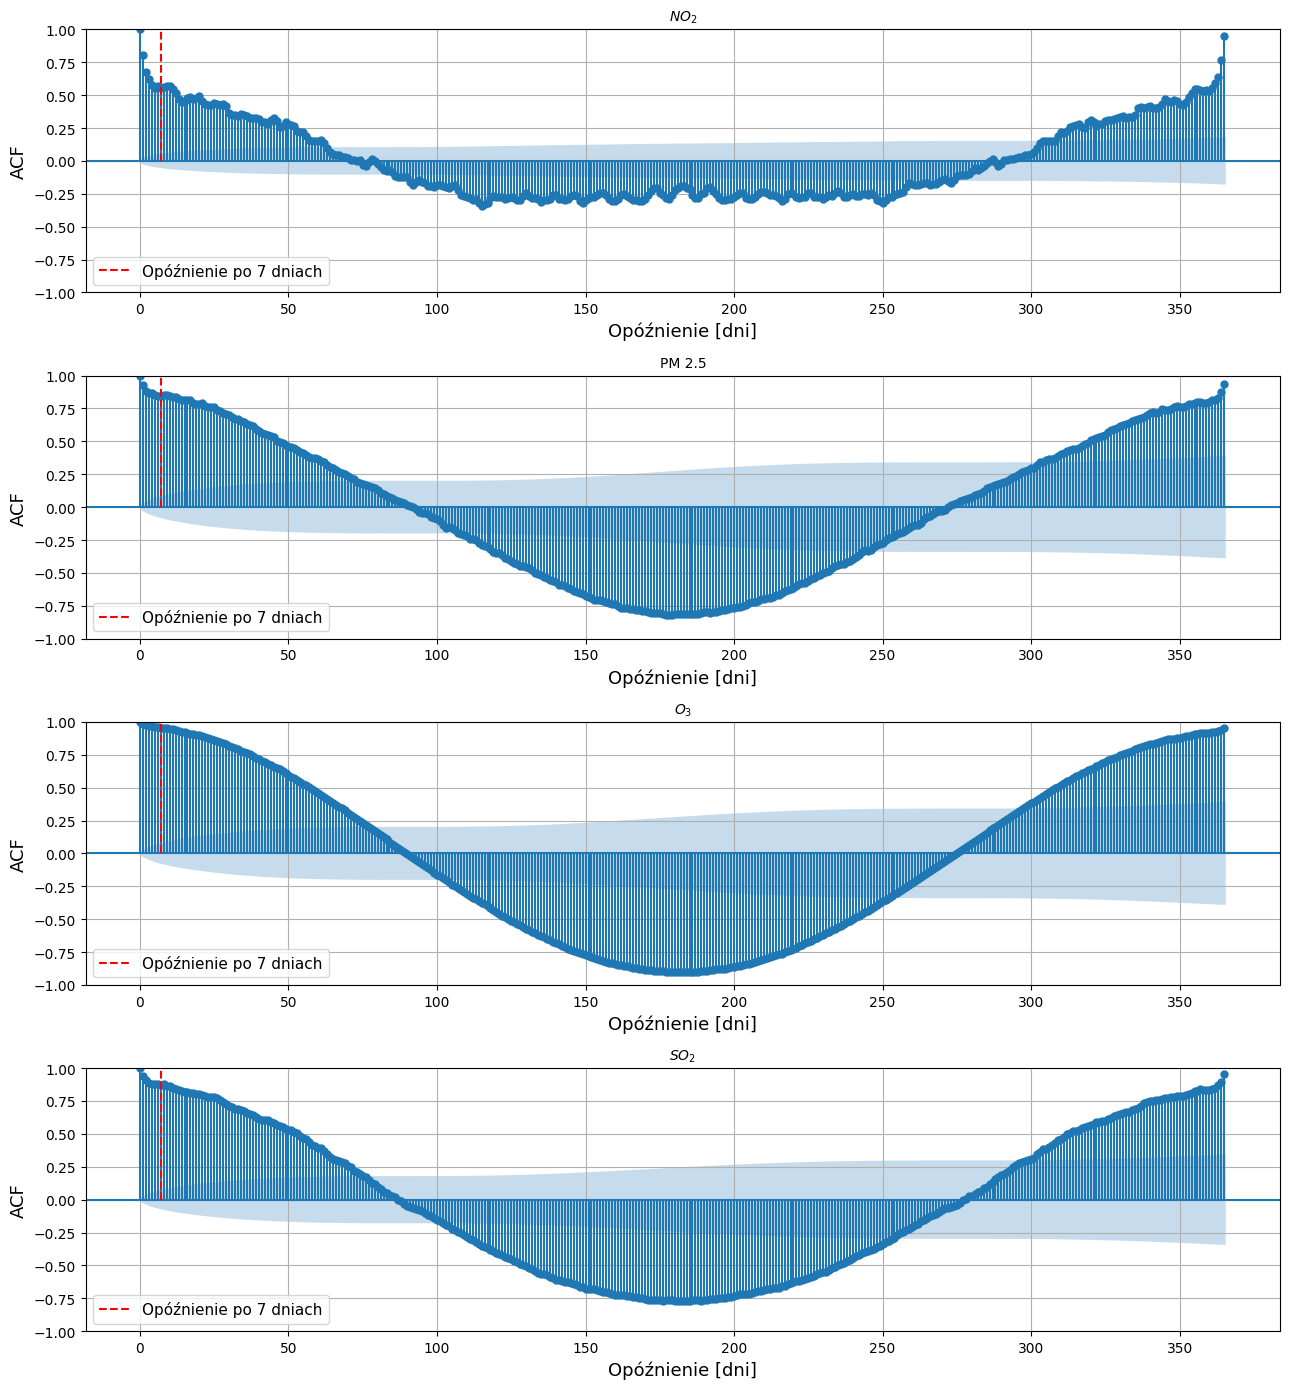

In [ ]:
acf_funkcja([sez_pl_no2.seasonal, sez_pl_pm.seasonal, sez_pl_o3.seasonal,sez_pl_so2.seasonal],[r'$NO_2$',r'$PM_2.5$',r'$O_3$', r'$SO_2$'],'Warszawie')

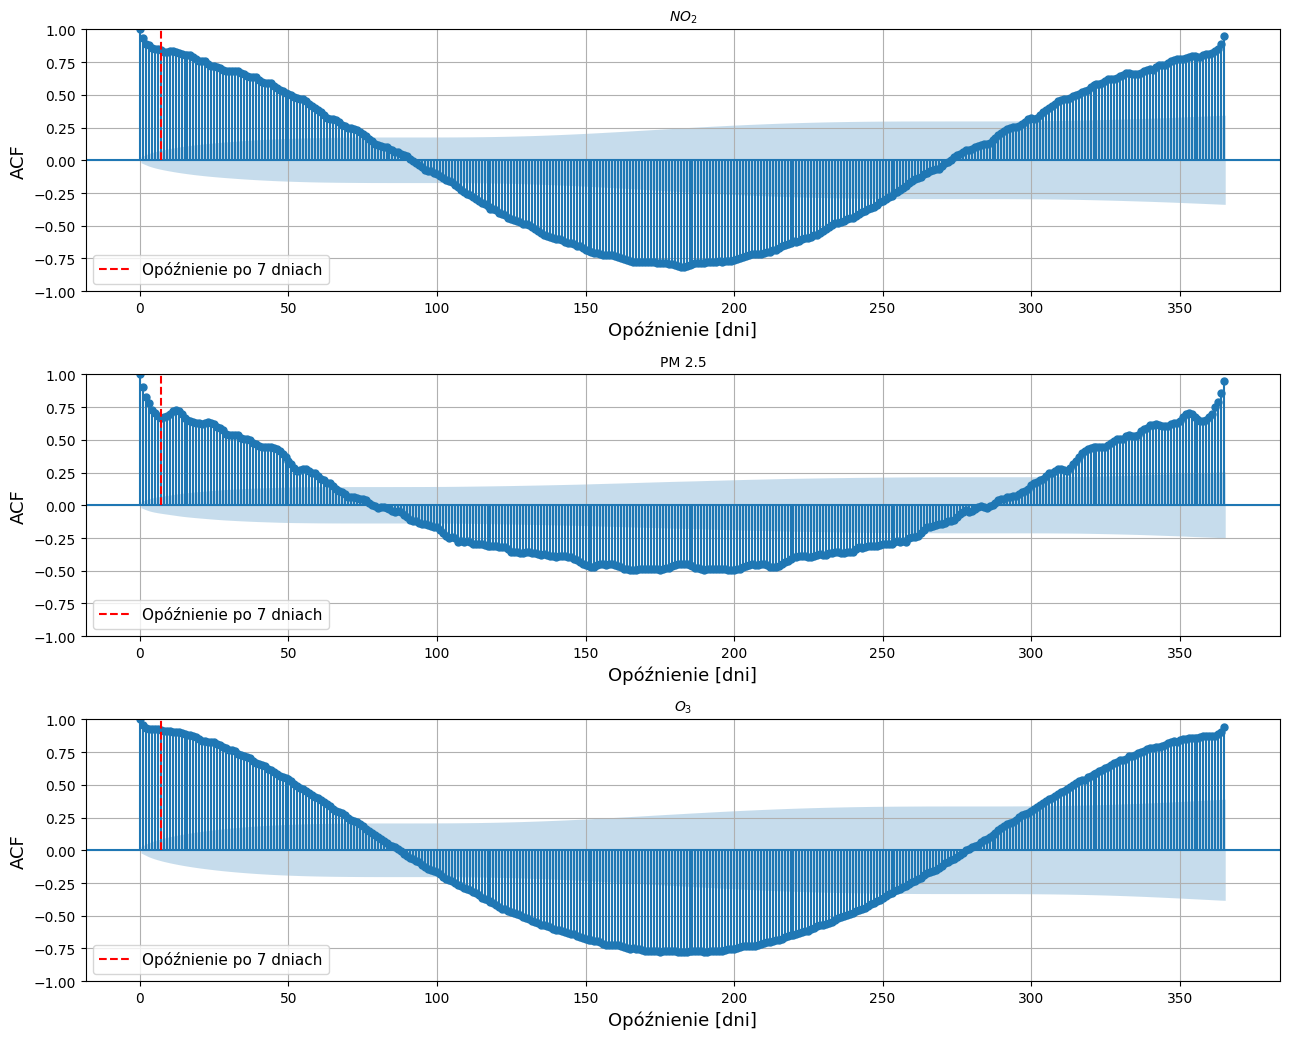

In [ ]:
acf_funkcja([sez_no_no2.seasonal,sez_no_pm.seasonal, sez_no_o3.seasonal],[r'$NO_2$',r'$PM_2.5$',r'$O_3$'],'Oslo')

#### PACF

In [ ]:
def pacf_funkcja(df, components, city, lag_num=365):
    n = len(df)
    fig, ax = plt.subplots(n,1,figsize=(13,3.5*n))
    plt.suptitle(f'PACF w {city}',fontsize=18)
    fig.supxlabel('Lag',fontsize=15)
   # fig.supylabel('PACF',fontsize=15)
    for i in range(n):
        plot_pacf(df[i], lags=lag_num,ax=ax[i])
        ax[i].axvline(x=7,color='red',ymin=0.5,ymax=1,linestyle='--',label='Opóźnienie po 7 dniach')
        ax[i].set_title(f'{components[i]}',fontsize=13)
        ax[i].set_xlabel('Opóźnienie [dni]',fontsize=13)
        ax[i].set_ylabel('PACF',fontsize=13)
        ax[i].grid(True)
    plt.tight_layout()
    plt.show()

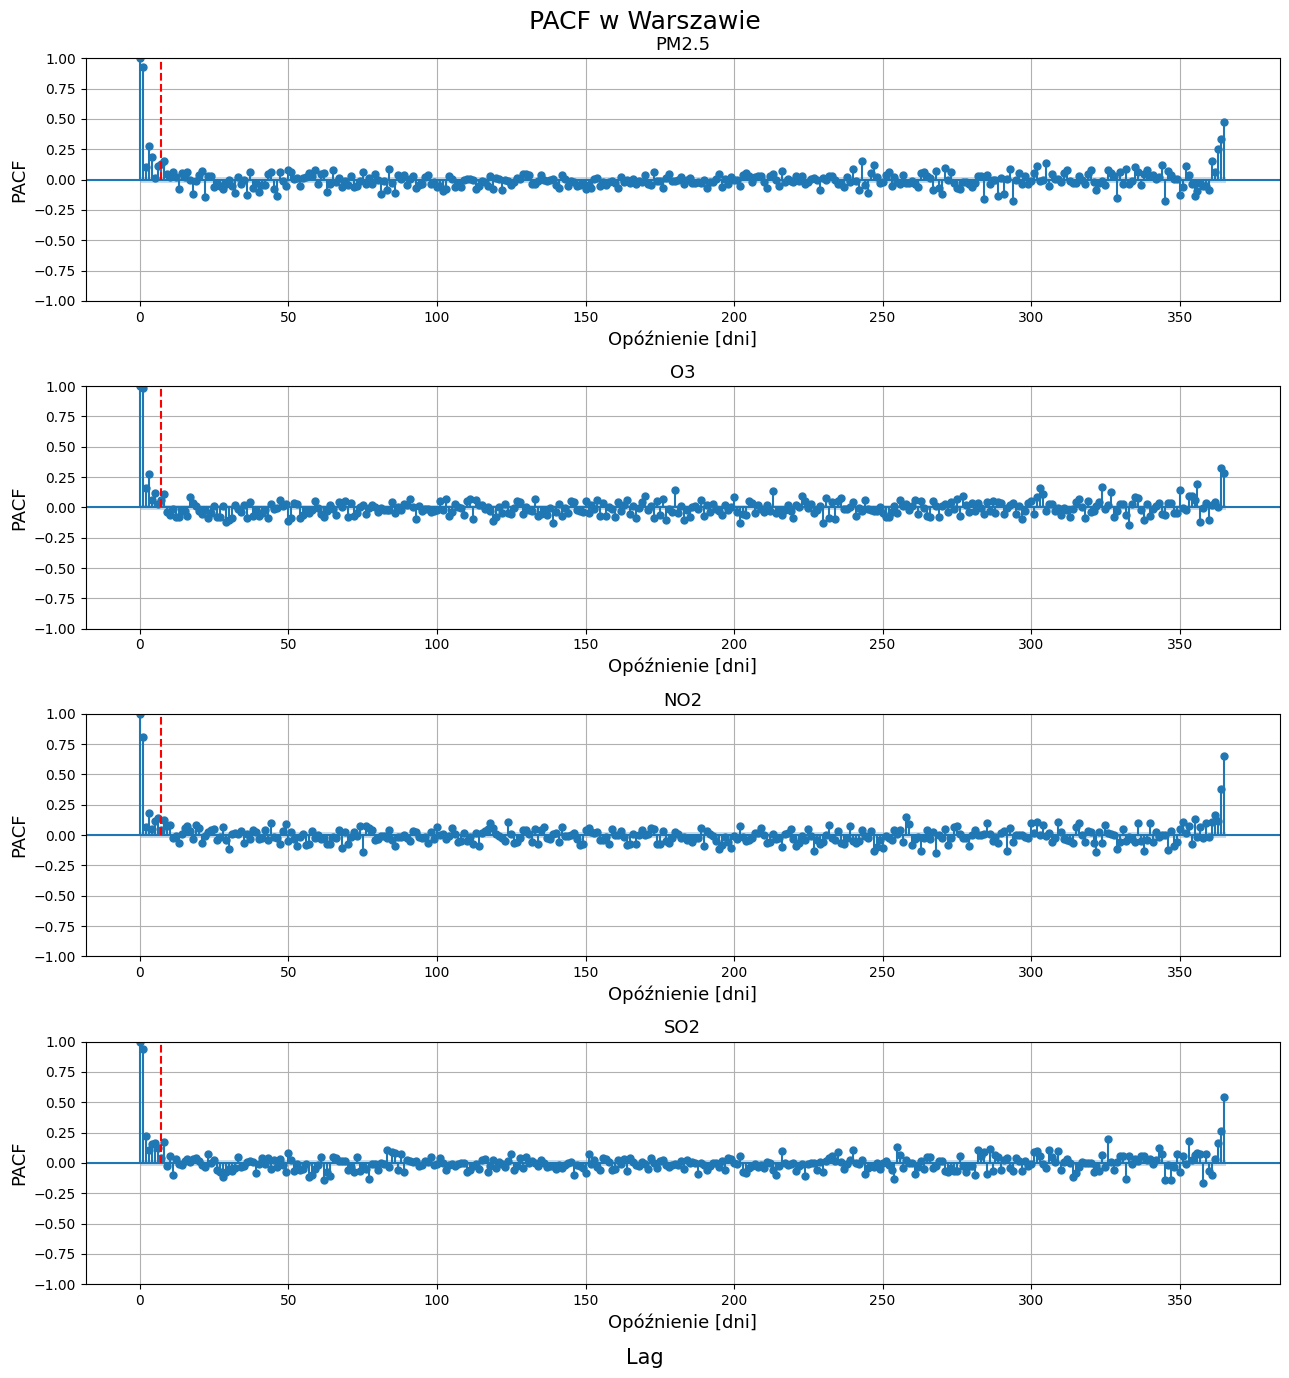

In [ ]:
pacf_funkcja([sez_pl_pm.seasonal, sez_pl_o3.seasonal,sez_pl_no2.seasonal,sez_pl_so2.seasonal],['PM2.5', 'O3','NO2','SO2'],'Warszawie')

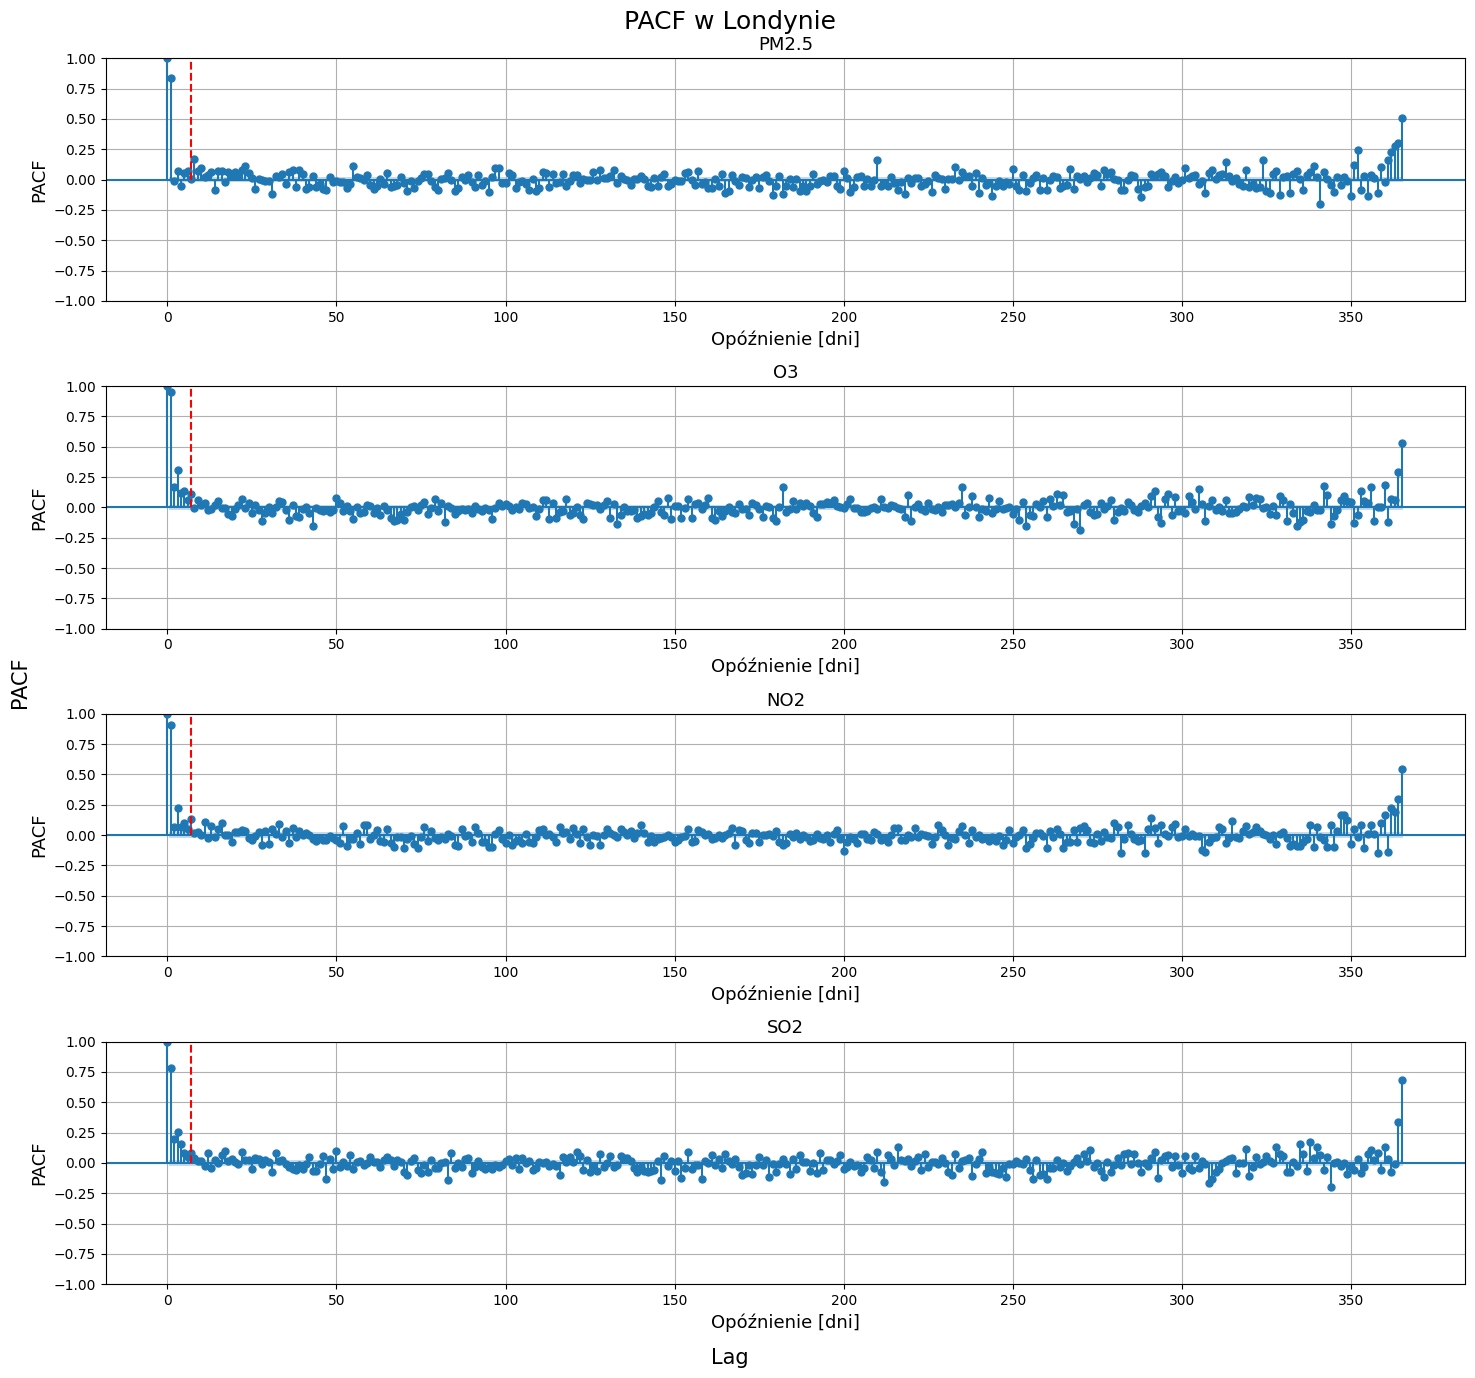

In [ ]:
pacf_funkcja([sez_uk_pm.seasonal, sez_uk_o3.seasonal,sez_uk_no2.seasonal,sez_uk_so2.seasonal],['PM2.5', 'O3','NO2','SO2'],'Londynie')

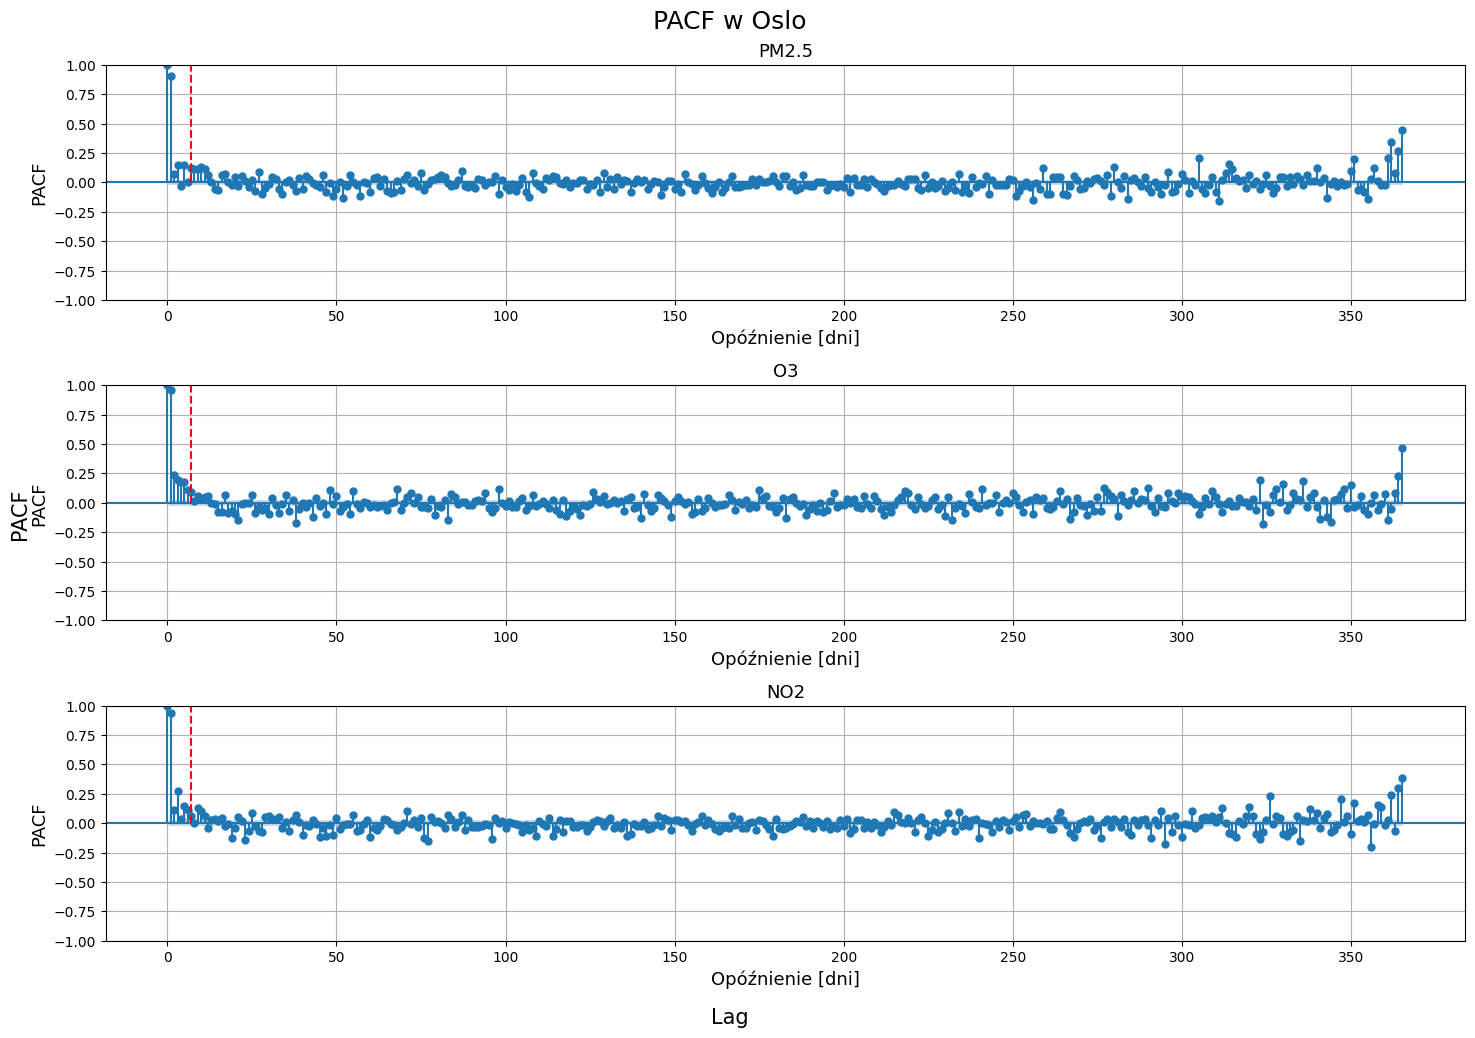

In [ ]:
pacf_funkcja([sez_no_pm.seasonal, sez_no_o3.seasonal,sez_no_no2.seasonal],['PM2.5', 'O3','NO2'],'Oslo')

#### Siła sezonowości

In [ ]:
decomp = [sez_uk_o3, sez_uk_no2, sez_uk_pm, sez_uk_so2, sez_pl_o3, sez_pl_no2, sez_pl_pm, sez_pl_so2, sez_no_o3, sez_no_no2, sez_no_pm]
decomp_names = [r'Londyn $O_3$', 'Londyn $NO_2$', 'Londyn $PM_{2.5}$', 'Londyn $SO_2$','Warszawa $O_3$', 'Warszawa $NO_2$', 'Warszawa $PM_{2.5}$', 'Warszawa $SO_2$','Oslo $O_3$', 'Oslo $NO_2$', 'Oslo $PM_{2.5}$']

In [ ]:
strength = []
for i,df in enumerate(decomp):
    var_R = df.resid.var()
    var_RS = (df.resid+df.seasonal).var()
    result = round(max(0, 1- var_R/var_RS),2)
    strength.append({'Zmienna': decomp_names[i], 'Siła sezonowości': result})

strength_sezonality = pd.DataFrame(strength)
strength_sezonality

,Zmienna,Siła sezonowości
0,Londyn $O_3$,0.33
1,Londyn $NO_2$,0.21
2,Londyn $PM_{2.5}$,0.10
3,Londyn $SO_2$,0.11
4,Warszawa $O_3$,0.58
5,Warszawa $NO_2$,0.11
6,Warszawa $PM_{2.5}$,0.34
7,Warszawa $SO_2$,0.27
8,Oslo $O_3$,0.39
9,Oslo $NO_2$,0.27


#### Siła trendu

In [ ]:
trend = []
for i,df in enumerate(decomp):
    var_R = df.resid.var()
    var_RS = (df.resid+df.trend).var()
    result = round(max(0, 1- var_R/var_RS),2)
    trend.append({'Zmienna': decomp_names[i], 'Siła trendu': result})

strength_trend = pd.DataFrame(trend)
strength_trend

,Zmienna,Siła trendu
0,Londyn $O_3$,0.09
1,Londyn $NO_2$,0.19
2,Londyn $PM_{2.5}$,0.13
3,Londyn $SO_2$,0.28
4,Warszawa $O_3$,0.05
5,Warszawa $NO_2$,0.10
6,Warszawa $PM_{2.5}$,0.16
7,Warszawa $SO_2$,0.43
8,Oslo $O_3$,0.46
9,Oslo $NO_2$,0.36


#### Średnie miesięczne wartości + wieloletni przebieg śred. miesięcznych

In [ ]:
from matplotlib.lines import Line2D

In [ ]:
month_names = ['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze','Lip', 'Sie', 'Wrz', 'Paź', 'Lis', 'Gru']

def miesieczne(df, components, city):
    n = len(df)
    fig, ax = plt.subplots(n,1,figsize=(15,3.9*n))
    if n==1:
        ax = [ax]
    plt.suptitle(f'Średnie miesięczne wartości w {city}',fontsize=18)
    for i, tab in enumerate(df):
        tab = tab.loc[tab.index >='2010-01-01', 'Pomiar'] # tylko dla wawy pm 2.5
        data = tab.resample('ME').mean()
        month_plot(data,ax=ax[i])
        ax[i].set_title(f'{components[i]}')
        ax[i].set_xlabel('Miesiąc',fontsize=14)
        ax[i].set_ylabel(f'Stężenie {components[i]} $[\\mu g/m^3]$',fontsize=14)
        ax[i].set_xticklabels(month_names)
        ax[i].grid(True,alpha=0.5)
        ax[i].legend(handles=[Line2D([0], [0], color='red', lw=2, label='Średnia miesięczna'),
                              Line2D([0], [0], color='black', lw=2, label='Wieloletni przebieg średnich miesięcznych')],
                              fontsize=11)
    plt.tight_layout()
    plt.show()

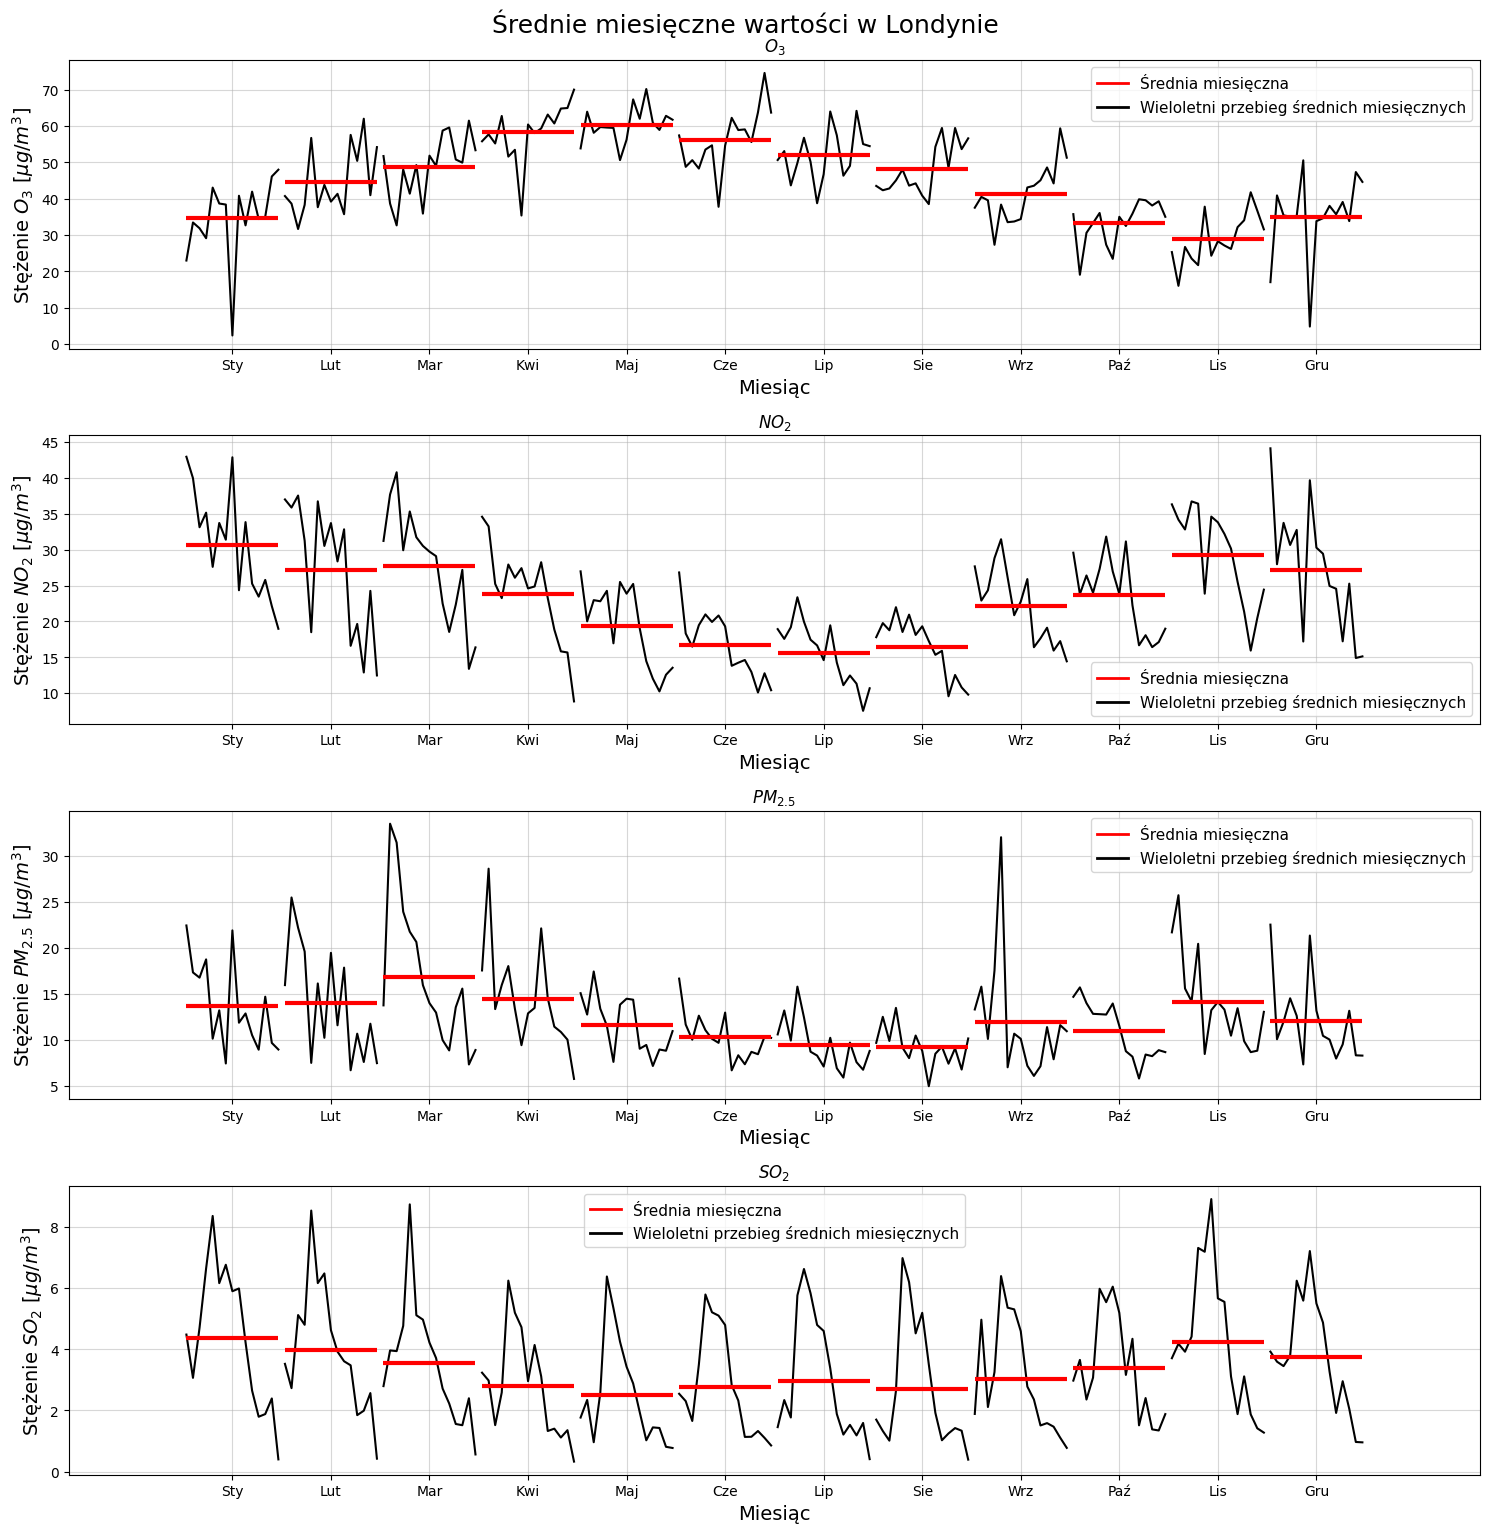

In [ ]:
miesieczne([uk_o3,uk_no2, uk_pm,uk_so2], [r'$O_3$',r'$NO_2$','$PM_{2.5}$',r'$SO_2$'],'Londynie')

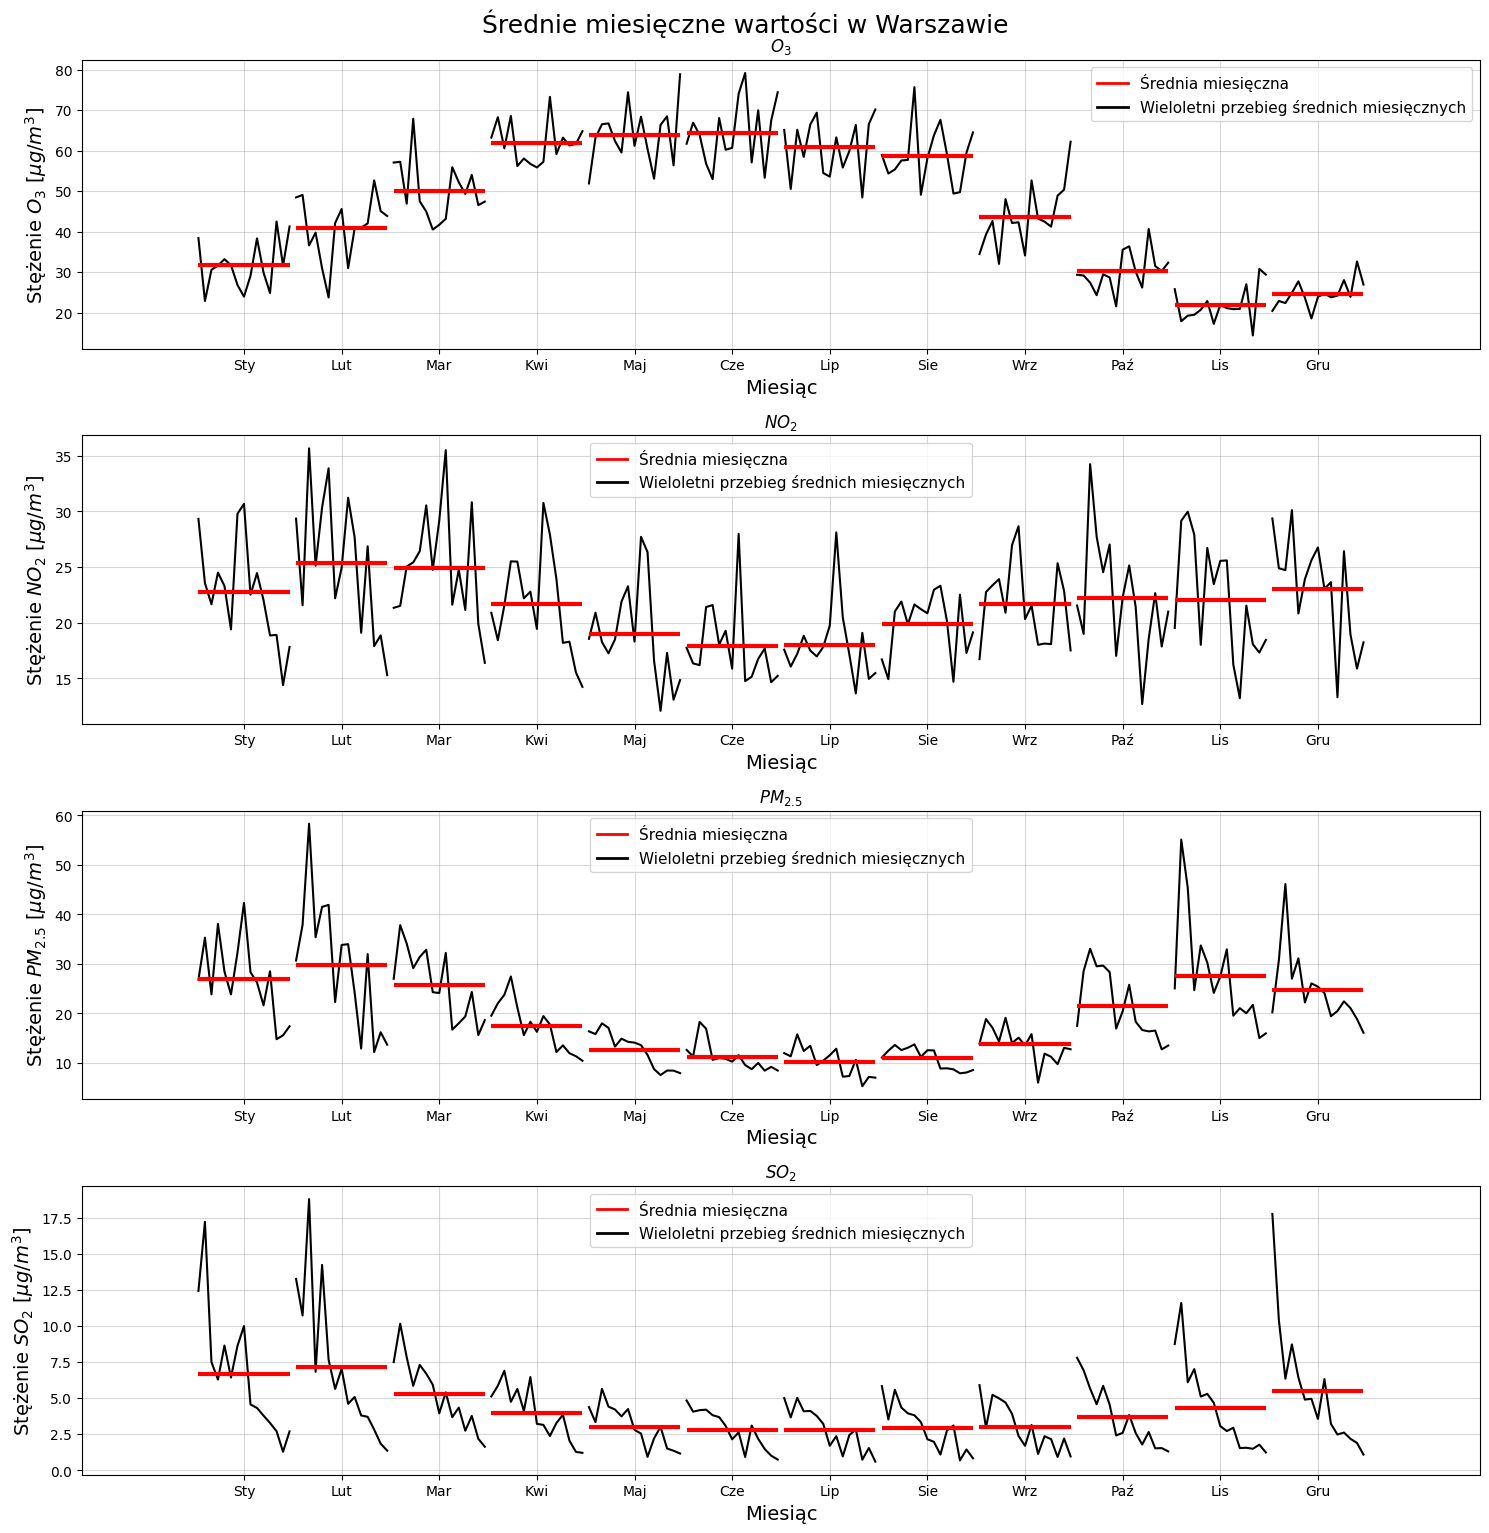

In [ ]:
miesieczne([pl_o3,pl_no2, pl_pm,pl_so2], [r'$O_3$',r'$NO_2$','$PM_{2.5}$',r'$SO_2$'],'Warszawie')

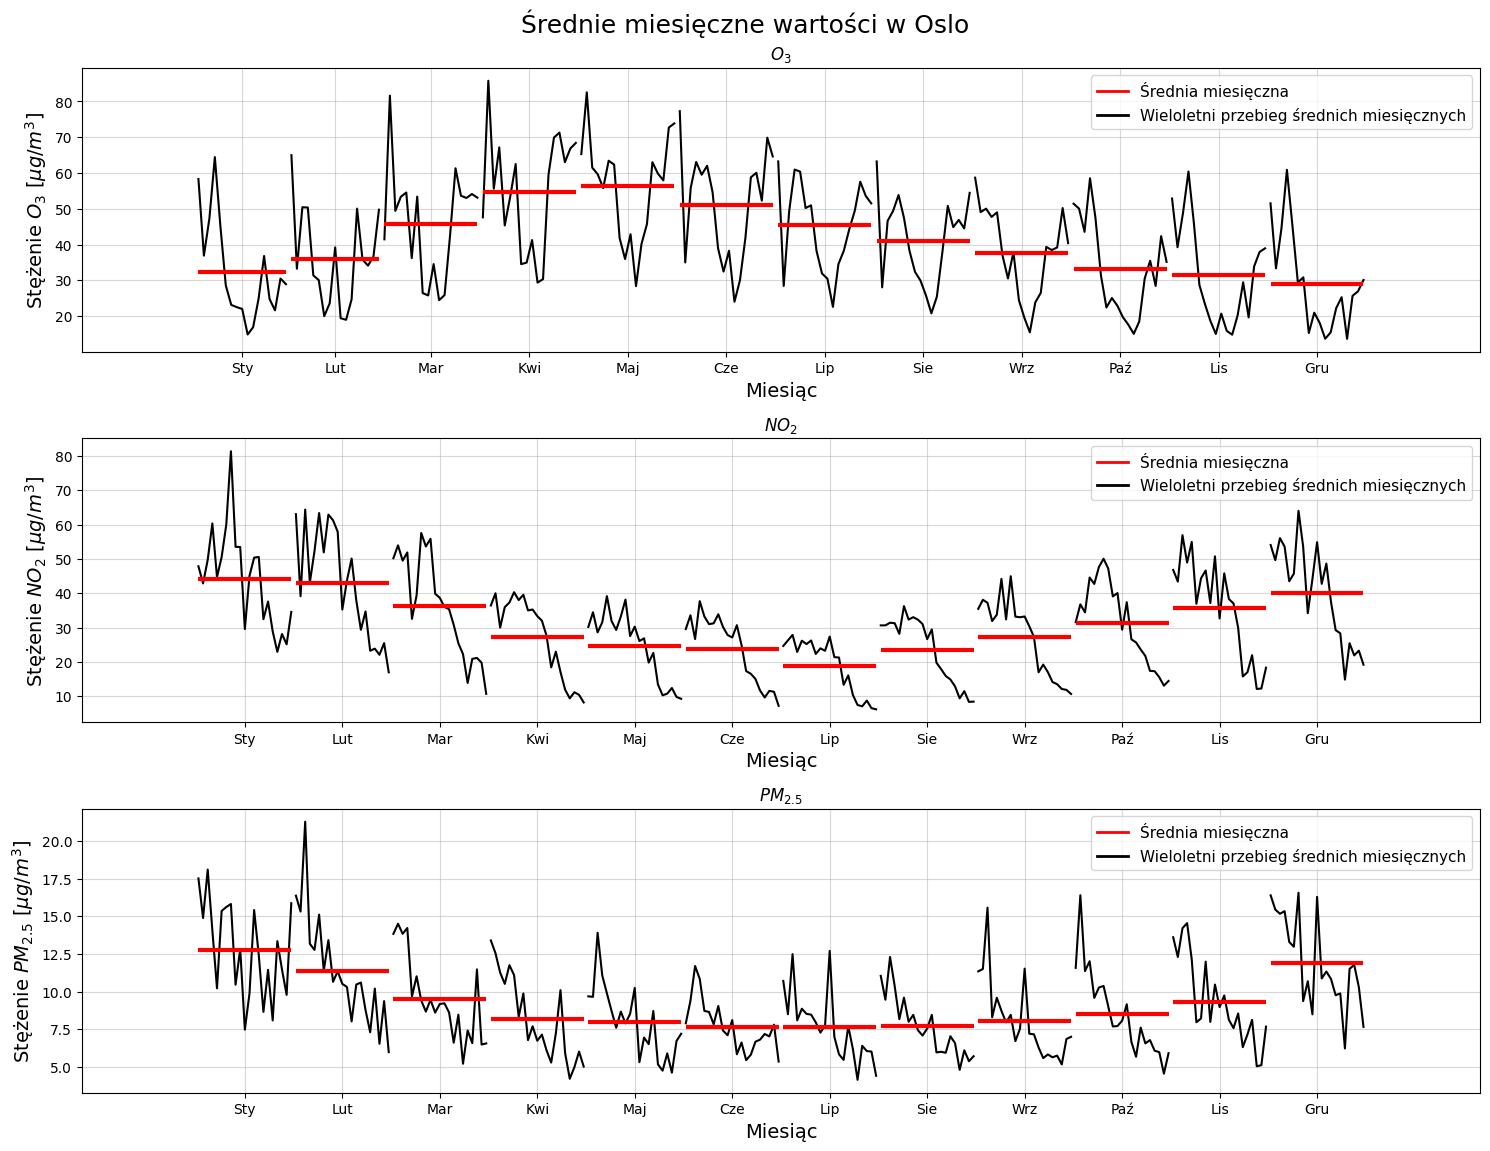

In [ ]:
miesieczne([no_o3,no_no2, no_pm], [r'$O_3$',r'$NO_2$','$PM_{2.5}$'],'Oslo')

### 5. Porównanie miast - Regresja liniowa + średnia ruchoma

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
reg_df = [uk_o3, uk_no2, uk_pm, uk_so2, pl_o3, pl_no2, pl_pm, pl_so2,no_o3, no_no2, no_pm] # w tej tablicy zmienne beda troche inne, obliczona bedzie dla nich regresja
dfs_names = ['Londyn O3', 'Londyn NO2', 'Londyn PM 2.5', 'Londyn SO2','Warszawa O3', 'Warszawa NO2', 'Warszawa PM 2.5', 'Warszawa SO2','Oslo O3', 'Oslo NO2', 'Oslo PM 2.5']

In [ ]:
a_df = pd.DataFrame(index = ['O3','NO2','PM 2.5','SO2'], columns=['Londyn','Warszawa','Oslo'])

for i,tab in enumerate(reg_df): # oblicza wspolczynnik a
    tab = tab['Pomiar'].resample('ME').mean().dropna().to_frame()
    y = tab.values
    X = np.arange(0, len(y)).reshape(-1, 1)
    reg = LinearRegression().fit(X,y)
    tab['Regression']= reg.predict(X)
    reg_df[i]=tab
    a_df.iloc[i%4,i//4] = reg.coef_[0].round(3)

In [ ]:
a_df

,Londyn,Warszawa,Oslo
O3,0.051,0.004,-0.057
NO2,-0.081,-0.024,-0.137
PM 2.5,-0.045,-0.077,-0.027
SO2,-0.012,-0.042,NaN


In [ ]:
city_col = ['#dd1c77','#4483d5','#58bd21']

def liniowa(df, component, city,win=12):
    n = len(df)
    metrics = pd.DataFrame(columns = ['Współczynnik A','R2','MAE','RMSE'], index=city)
    fig, ax = plt.subplots(figsize=(15,6))
    for k,tab in enumerate(df):
        tab = tab.copy()
        tab['srednia'] = tab['Pomiar'].rolling(window=win).mean()
        ax.plot(tab.index, tab['srednia'],color=city_col[k], label=f'{city[k]} (MA)',lw=2.5,linestyle='--',alpha=0.6)
        ax.plot(tab.index,tab['Regression'], color=city_col[k],label=f'{city[k]} (Regresja)',lw=2.5)

        # obliczanie metryk
        y = tab['srednia'].dropna()
        y_pred = tab.loc[y.index,'Regression']
       # metrics.loc[city[k],'R2'] = round(r2_score(y,y_pred),2)
        #metrics.loc[city[k],'MAE'] =  round(mean_absolute_error(y,y_pred),2)
        #metrics.loc[city[k],'RMSE'] =  round(np.sqrt(mean_squared_error(y,y_pred)),2)
    ax.legend(loc='upper right',fontsize=9)
    ax.set_ylabel('Wartość [μg/m3]',fontsize=12)
    ax.set_xlabel('Data',fontsize=12)
    ax.set_title(component,fontsize=15)
    ax.grid(True,alpha=0.6)
    plt.tight_layout()
    plt.show()
    #return metrics

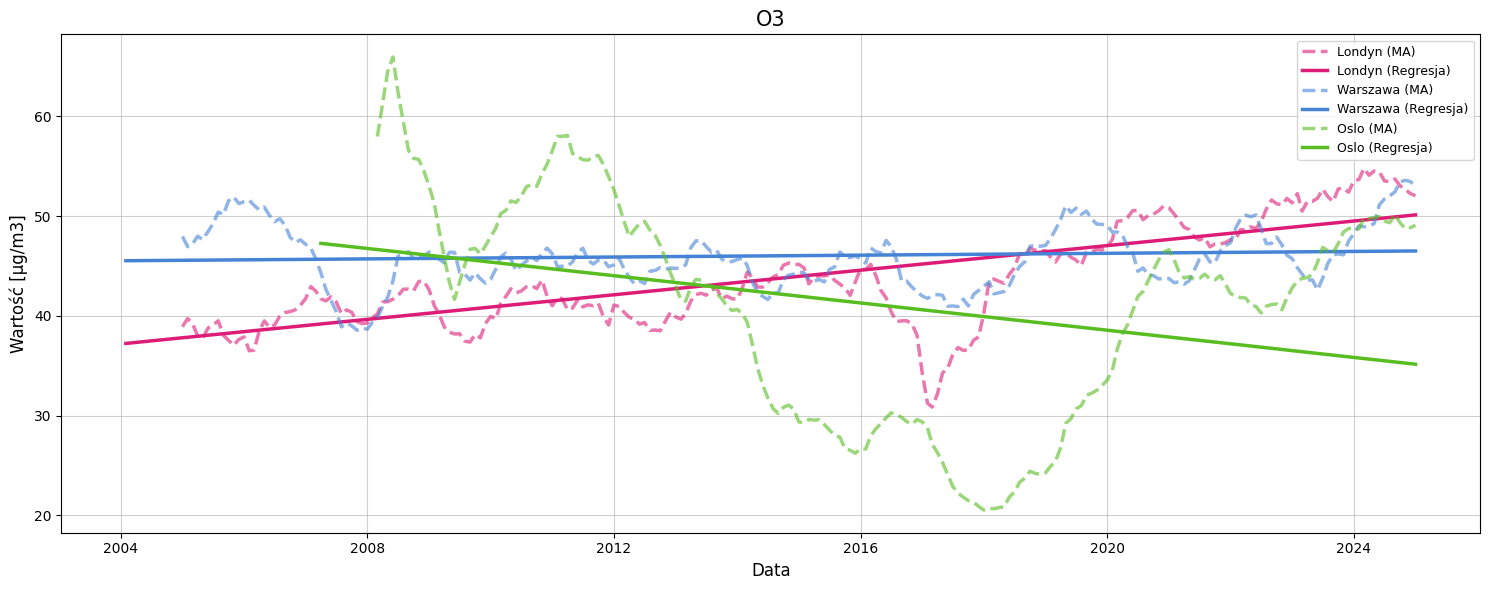

In [ ]:
liniowa(reg_df[0::4],'O3',['Londyn','Warszawa','Oslo'])

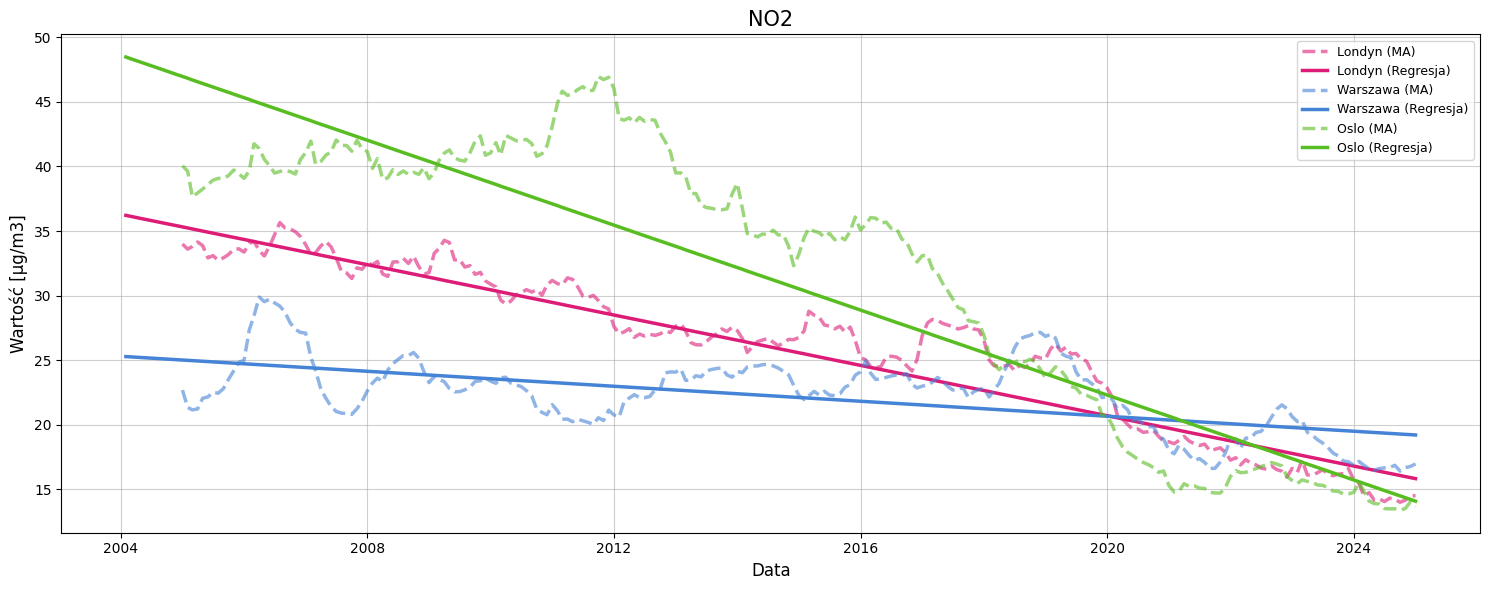

In [ ]:
liniowa(reg_df[1::4],'NO2',['Londyn','Warszawa','Oslo'])

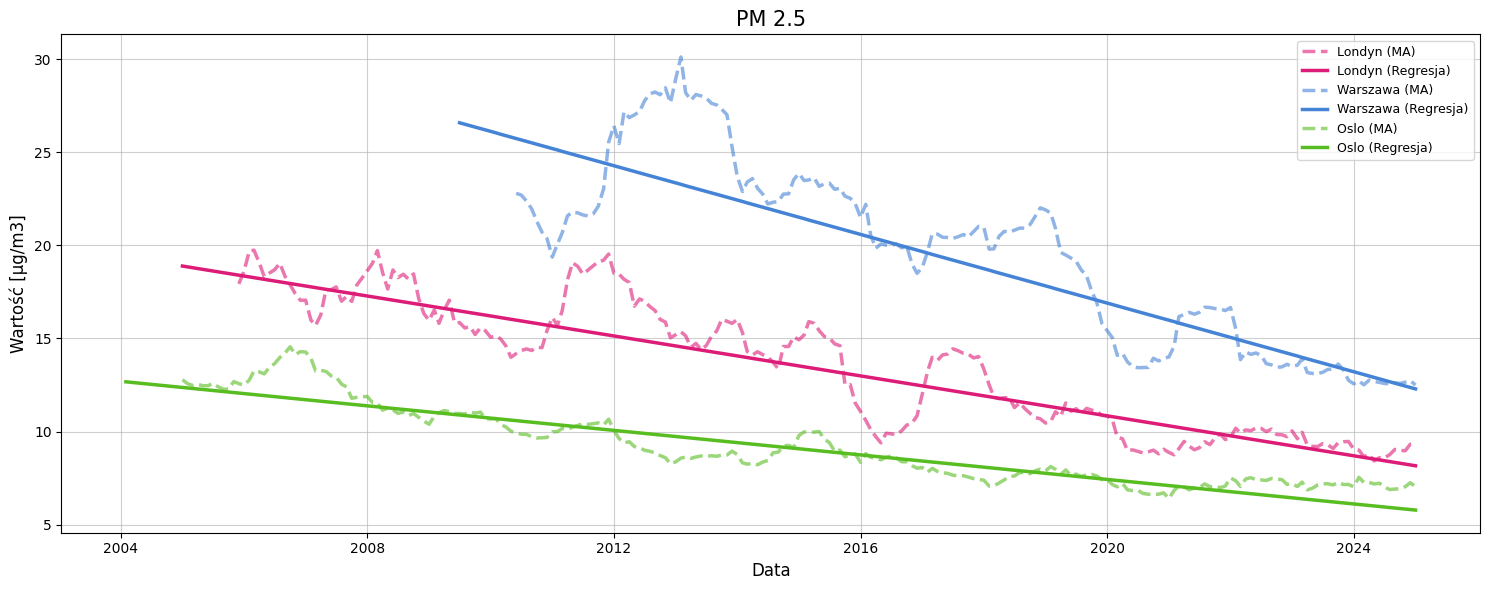

In [ ]:
liniowa(reg_df[2::4],'PM 2.5',['Londyn','Warszawa','Oslo'])

### 6. Regresja nieliniowa + średnia ruchoma

In [ ]:
reg_df = [uk_o3, uk_no2, uk_pm, uk_so2, pl_o3, pl_no2, pl_pm, pl_so2,no_o3, no_no2, no_pm] # w tej tablicy zmienne beda troche inne, obliczona bedzie dla nich regresja
dfs_names = ['Londyn O3', 'Londyn NO2', 'Londyn PM 2.5', 'Londyn SO2','Warszawa O3', 'Warszawa NO2', 'Warszawa PM 2.5', 'Warszawa SO2','Oslo O3', 'Oslo NO2', 'Oslo PM 2.5']

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess

a_df = pd.DataFrame(index = ['O3','NO2','PM 2.5','SO2'], columns=['Londyn','Warszawa','Oslo'])

for i, tab in enumerate(reg_df):
    tab = tab['Pomiar'].resample('ME').mean().dropna().to_frame()
    y = tab['Pomiar'].values
    X = np.arange(len(y))
    low = lowess(y, X, frac=0.2)
    tab['Regression'] = low[:, 1]  # metoda lowess
    reg_df[i] = tab

In [ ]:
city_col = ['#dd1c77','#4483d5','#58bd21']

def nieliniowa(df, component, city,win=12):
    n = len(df)
    metrics = pd.DataFrame(columns = ['Współczynnik A','R2','MAE','RMSE'], index=city)
    fig, ax = plt.subplots(figsize=(15,6))
    for k,tab in enumerate(df):
        tab = tab.copy()
        tab['srednia'] = tab['Pomiar'].rolling(window=win, center=True).mean()
        ax.plot(tab.index, tab['srednia'],color=city_col[k], label=f'{city[k]} (Średnia ruchoma)',lw=2.5,linestyle='--',alpha=0.6)
        ax.plot(tab.index,tab['Regression'], color=city_col[k],label=f'{city[k]} (Regresja)',lw=2.5)
    ax.legend(loc='upper right',fontsize=9)
    ax.set_ylabel(f'Stężenie {component} $[\\mu g/m^3]$',fontsize=13)
    ax.set_xlabel('Rok',fontsize=12)
    ax.set_title(component,fontsize=15)
    ax.grid(True,alpha=0.6)
    plt.tight_layout()
    plt.show()

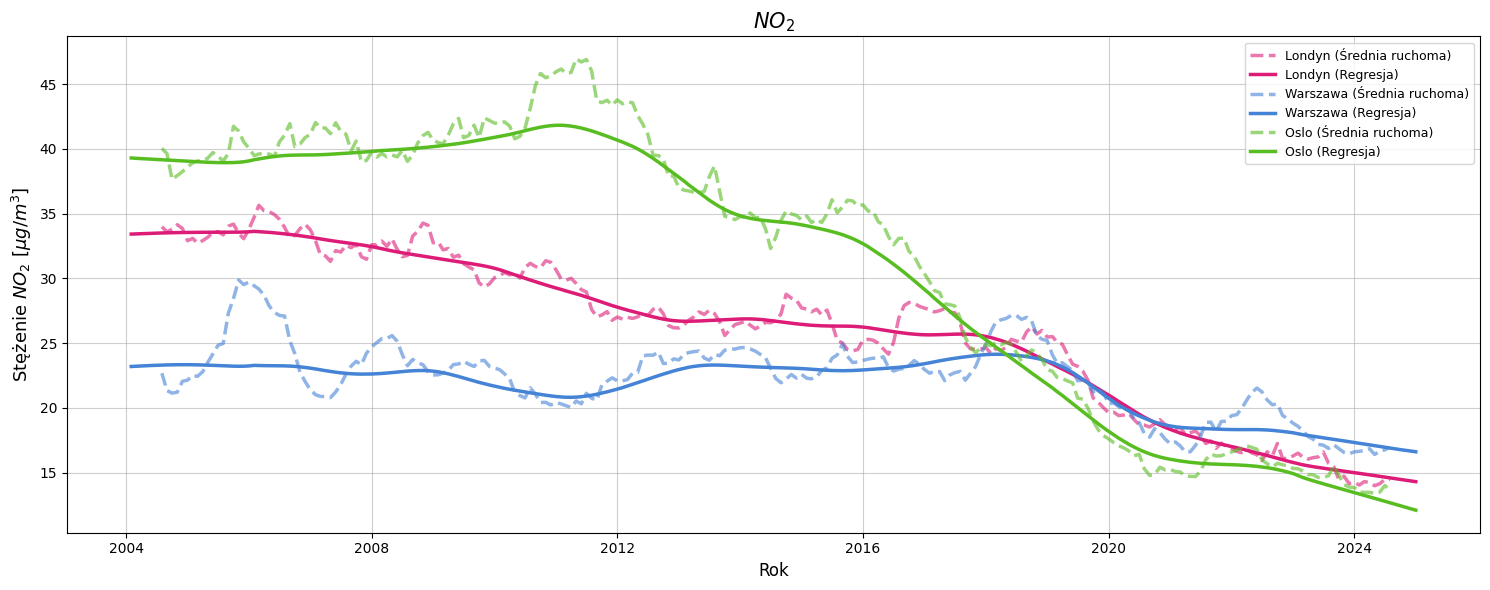

In [ ]:
nieliniowa(reg_df[1::4],r'$NO_2$',['Londyn','Warszawa','Oslo'])

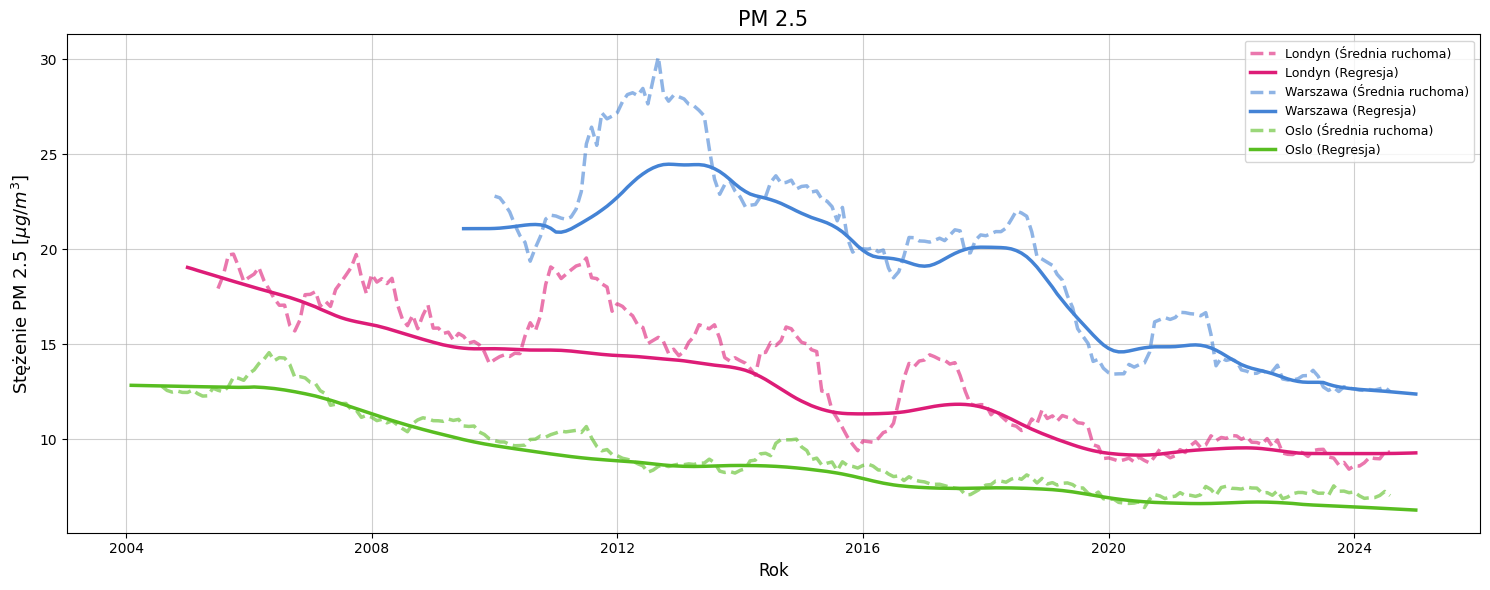

In [ ]:
nieliniowa(reg_df[2::4],'PM 2.5',['Londyn','Warszawa','Oslo'])

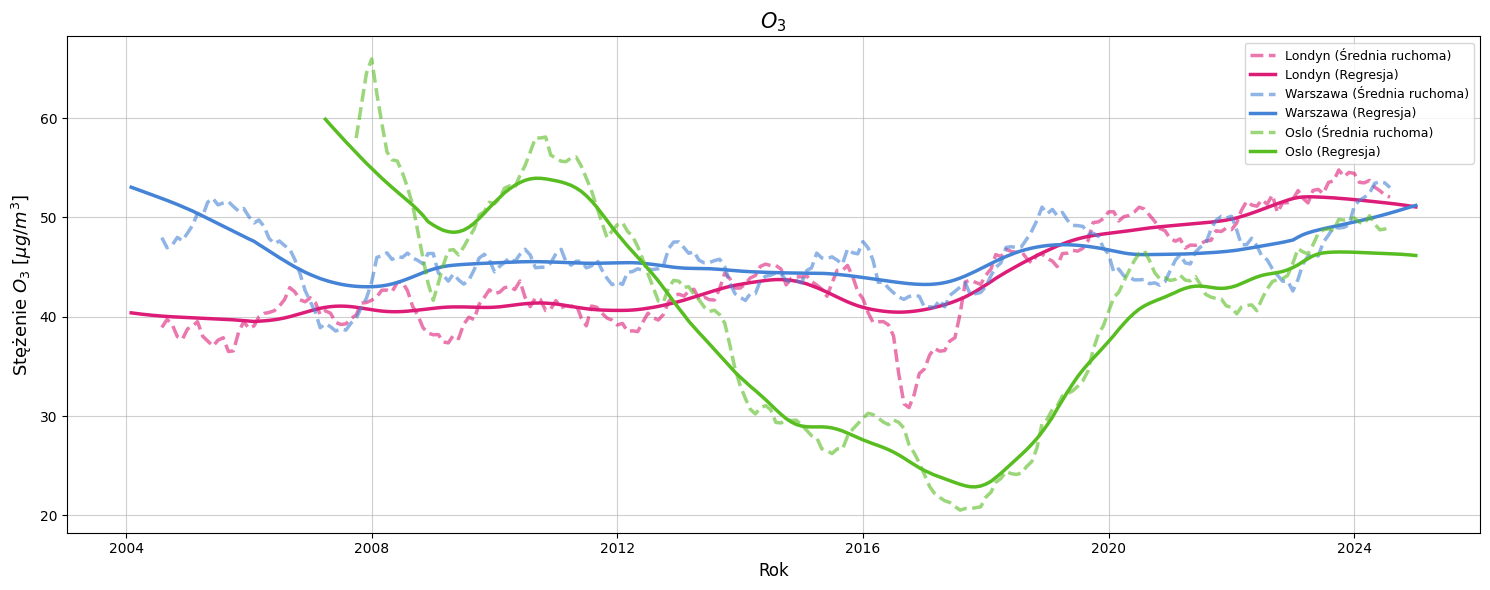

In [ ]:
nieliniowa(reg_df[0::4],r'$O_3$',['Londyn','Warszawa','Oslo'])

### 7. Analiza tygodniowa

In [ ]:
col_tyg = ['#FFD7C4', '#9EC6F3','#FFCCE1','#DAD2FF', '#F9B487','#E06B80','#B7A3E3']

In [ ]:
day_names = ['Poniedziałek', 'Wtorek','Środa','Czwartek','Piątek','Sobota','Niedziela']

def tygodniowy(df, component, city):
    n = len(df)
    fig, ax = plt.subplots(n,1,figsize=(15,4.4*n))
    plt.suptitle(f'Tygodniowy rozkład {component}',fontsize=18)
    #fig.supxlabel('Dzień tygodnia',fontsize=15)
    #fig.supylabel('Wartość pomiaru',fontsize=15)
    for k,tab in enumerate(df):
        tab = tab.copy()
        tab.loc[:,'Nazwa_dnia'] = tab.index.day_name()
        sns.boxplot(data=tab,x='Nazwa_dnia', y='Pomiar',hue='Nazwa_dnia',palette=col_tyg,ax=ax[k],fliersize=3.5,
                       order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
        ax[k].set_title(f'w {city[k]}', fontsize=15)
        ax[k].set_ylabel(f'Stężenie {component} $[\\mu g/m^3]$',fontsize=13)
        ax[k].set_xlabel('Dzień tygodnia',fontsize=13)
        ax[k].set_xticklabels(day_names)
        ax[k].grid(True,alpha=0.7)
    plt.tight_layout(pad=2.5)
    plt.show()

D:\TEMP\ipykernel_2320\1359090882.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[k].set_xticklabels(day_names)
D:\TEMP\ipykernel_2320\1359090882.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[k].set_xticklabels(day_names)
D:\TEMP\ipykernel_2320\1359090882.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[k].set_xticklabels(day_names)


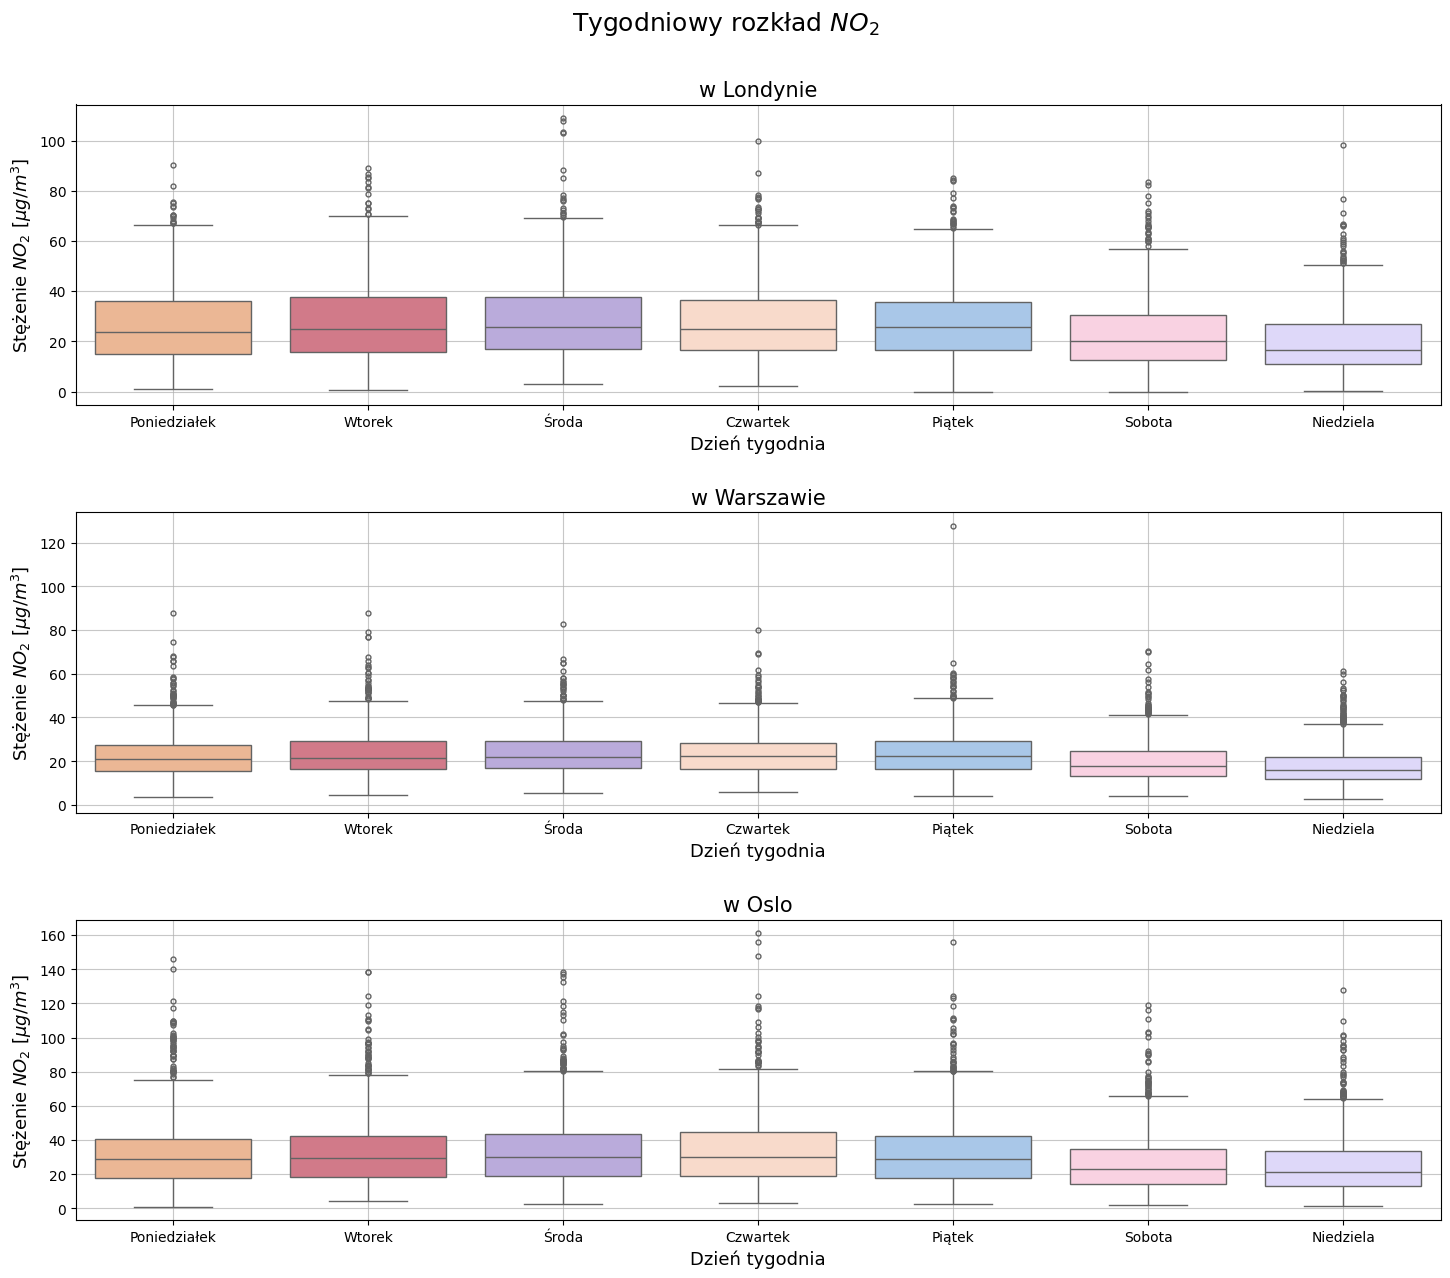

In [ ]:
tygodniowy([uk_no2, pl_no2, no_no2],r'$NO_2$', ['Londynie','Warszawie','Oslo'])

D:\TEMP\ipykernel_2432\2565810977.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[k].set_xticklabels(day_names)
D:\TEMP\ipykernel_2432\2565810977.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[k].set_xticklabels(day_names)
D:\TEMP\ipykernel_2432\2565810977.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[k].set_xticklabels(day_names)


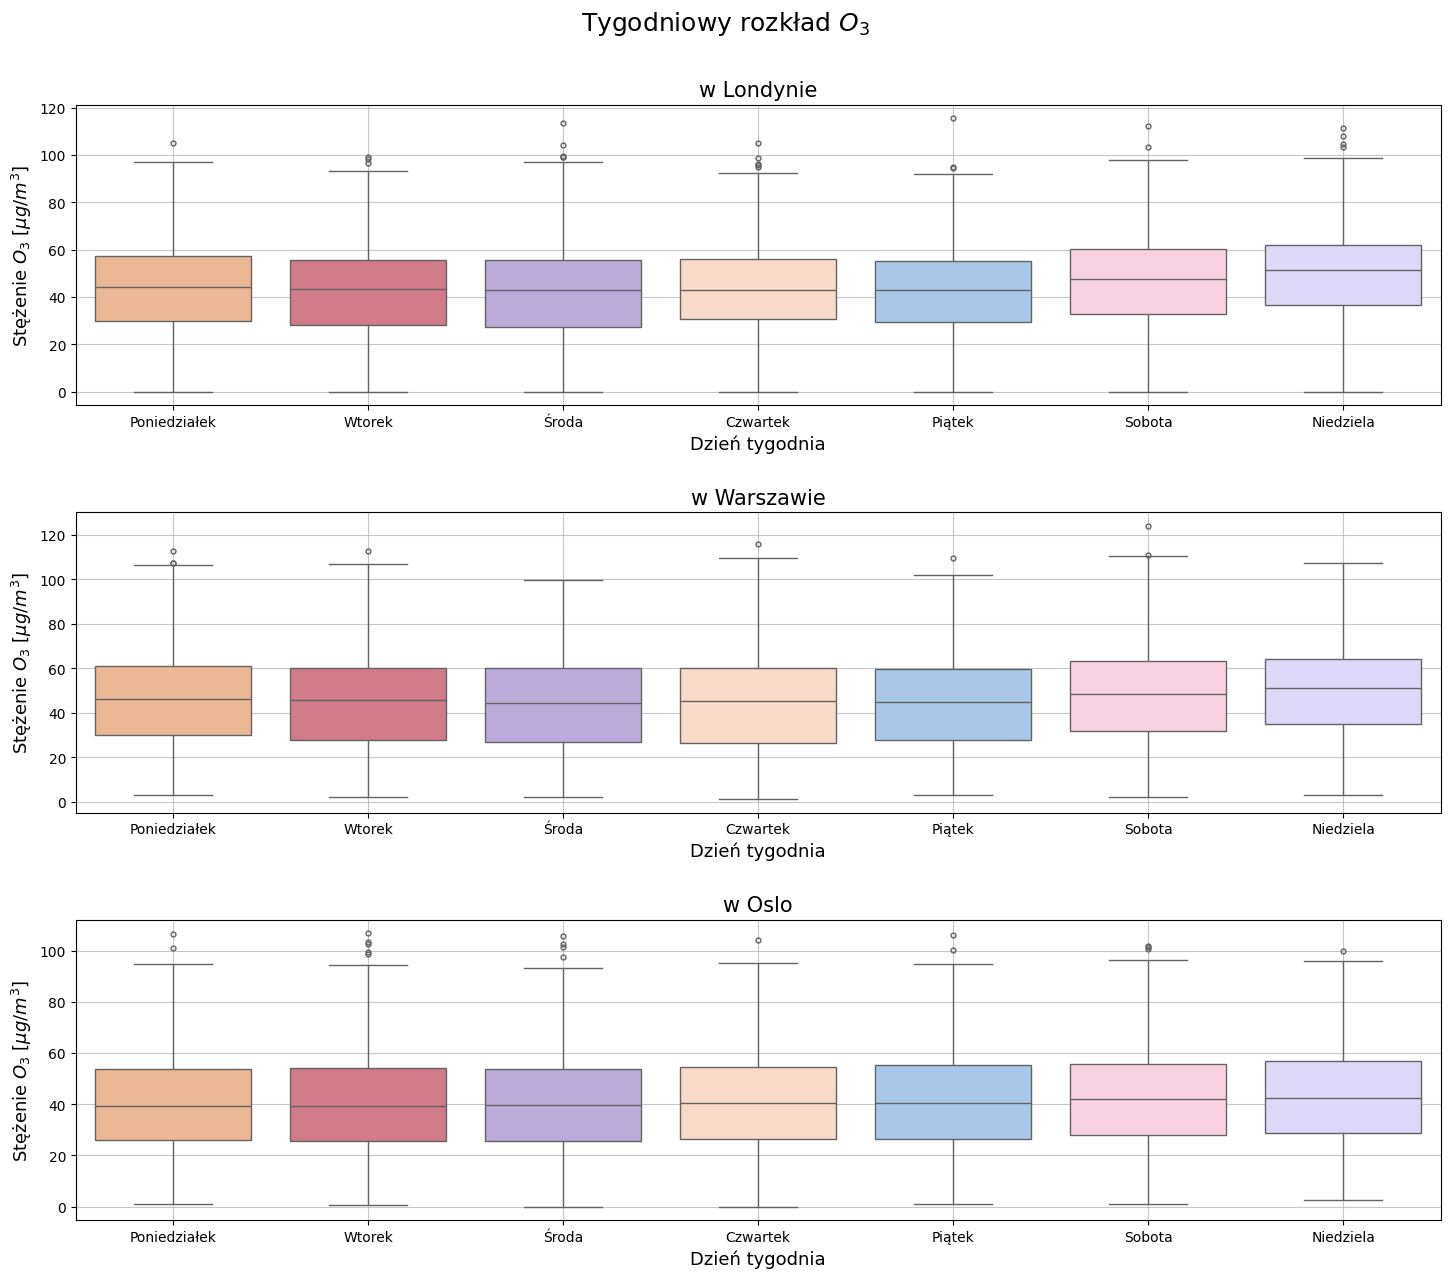

In [ ]:
tygodniowy([uk_o3, pl_o3, no_o3],r'$O_3$', ['Londynie','Warszawie','Oslo'])

D:\TEMP\ipykernel_2320\1359090882.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[k].set_xticklabels(day_names)
D:\TEMP\ipykernel_2320\1359090882.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[k].set_xticklabels(day_names)
D:\TEMP\ipykernel_2320\1359090882.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[k].set_xticklabels(day_names)


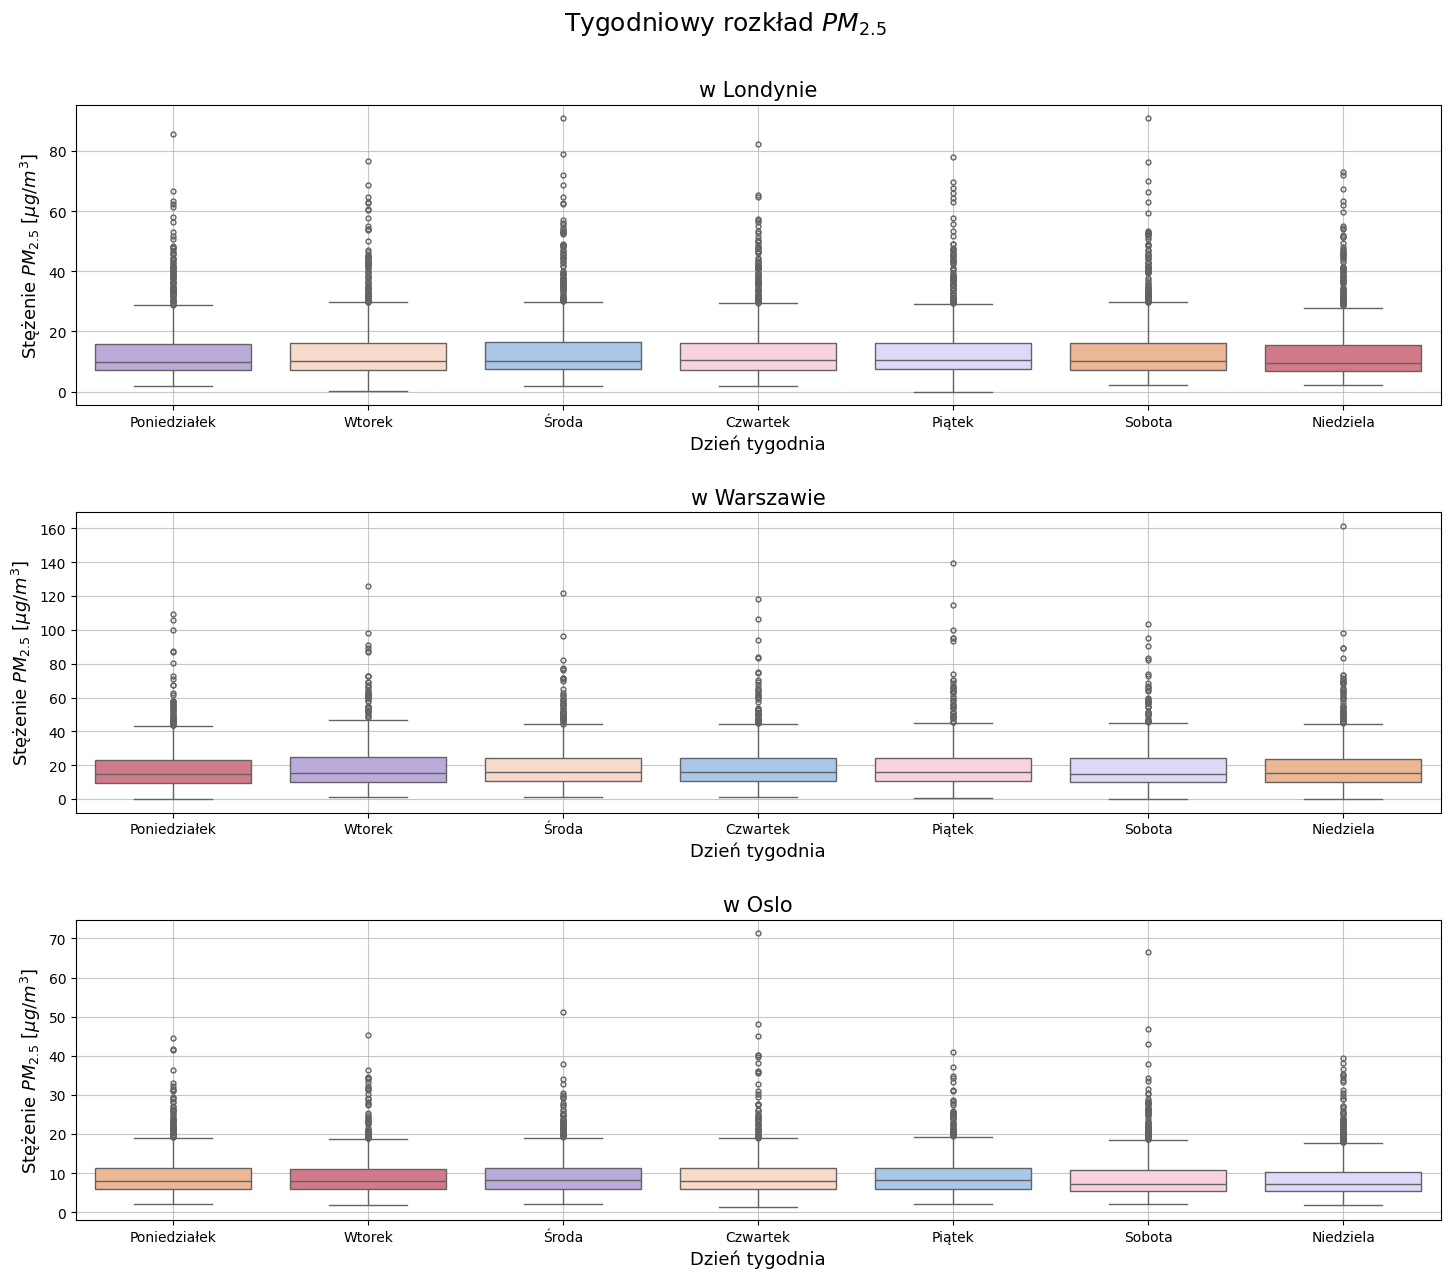

In [ ]:
tygodniowy([uk_pm, pl_pm, no_pm],r'$PM_{2.5}$', ['Londynie','Warszawie','Oslo'])

#### test kruskal-wallisa

In [ ]:
from scipy import stats

In [ ]:
def test_kruskal1(df):
    df['day'] = df.index.day_name()
    pon = df[df['day']=='Monday']['Pomiar']
    wt = df[df['day']=='Tuesday']['Pomiar']
    sr = df[df['day']=='Wednesday']['Pomiar']
    czw = df[df['day']=='Thursday']['Pomiar']
    pt = df[df['day']=='Friday']['Pomiar']
    sob = df[df['day']=='Saturday']['Pomiar']
    ndz = df[df['day']=='Sunday']['Pomiar']
    result = stats.kruskal(pon, wt, sr, czw, pt, sob, ndz)
    print(result)

In [ ]:
test_kruskal1(uk_no2)

KruskalResult(statistic=345.5014736950068, pvalue=1.4260867417139564e-71)


In [ ]:
test_kruskal1(uk_pm)

KruskalResult(statistic=20.167611713316283, pvalue=0.0025853980269243382)
